# Pedro algorithm versus Score base model — eight scenarios

This is the **correct two-algorithm comparison** requested by Payam. It is NOT the matched-estimator control experiment from notebook 14.

| Algorithm | Next query S | Parameter estimate after observing Y |
|---|---|---|
| **Pedro algorithm** | Uniform random candidate | Incenter of the hard-consistency cone |
| **Score base model** | Maximum disagreement across parameter samples | Mean of 16 parameter samples |

The Score base model uses the current corrected Gaussian-augmented slice sampler, not the original unadjusted v2 Euler sampler. Its loss and bounded parameter target are unchanged. This compares the complete algorithms: BOTH estimation and query selection differ.

**Protocol:** eight predeclared 4D/6D families, seeds 0–4, T=20, 120 candidate queries and 120 fresh held-out queries per test distribution. MIN expert, parameter noise, no observation noise (Y=X). All algorithms continue to T, even after zero regret or an invalid estimate. No large-dimensional experiments or training epochs are used.

F(theta,s,x)=theta dot (s*x). The true parameter is fixed within each run and shared by paired algorithms. Seeds vary both theta and noise; candidate pools and test sets are constructed independently of theta and are fixed across seeds. Cases 4/7/8 share theta, queries and tests to isolate noise changes. Standardized Gaussian parameter perturbations are paired across algorithms. The expert's perturbed parameter is normalized, which does not change hard-MIN decisions.

**Failures are part of the result.** Invalid estimates have no reported angular error or regret. We do NOT replace failure with 90/180 degrees, zero regret, or a softened incenter. Every aggregate over valid runs is explicitly conditional, with its valid count out of five. Individual runs and failure counts remain visible.

**Read without running:** all tables and plots are saved in this notebook. Each scenario has every-step mean tables, all five seed trajectories, query heatmaps, estimator diagnostics, and expandable tables containing every parameter/query/observed decision. Displayed vectors are rounded; raw checkpoints retain full precision.

**Rerun:** the code below reuses checkpoints only when source, configurations and test designs match. If checkpoints are absent, it runs the 80 experiments itself. An interrupted run can resume. Checkpoints live under outputs/active/15_pedro_vs_score_base.

Finite sampler budgets are not convergence-certified. Score base's loss target is not the exact Gaussian-noise likelihood. Zero regret on finitely many tests does not imply exact parameter recovery.
The independent cone audit at the end distinguishes a failed zero incenter from a cone with no nonzero feasible direction.


In [1]:
from pathlib import Path
import sys, json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
from invoptlab.active import (
    NestedLangevinConfig, PublicDecisionProblem, make_decision_space,
    build_pedro_score_scenarios, run_pedro_score_design,
)

SEEDS, T = (0,1,2,3,4), 20
LABELS = ("Pedro algorithm", "Score base model")
COLORS = {"Pedro algorithm":"#777777", "Score base model":"#0077bb"}
CFG = NestedLangevinConfig(
    sampler="gaussian_gibbs", theta_samples=16, point_estimate="mean",
    query_policy="disagreement", query_tie_breaking="random", beta=20.,
    parameter_domain="box", bound=1., tau_schedule=(.5,.1,.02),
    gibbs_sweeps=6, conditional_slice_steps=4, target_slice_steps=32,
    radial_refresh=True, record_chain_trace=False, workers=1,
)
OUTPUT = ROOT/"outputs"/"active"/"15_pedro_vs_score_base"
DESIGNS = {seed: build_pedro_score_scenarios(seed=seed, horizon=T) for seed in SEEDS}
ALL_RUNS = {}
plt.rcParams.update({"figure.dpi":100, "axes.grid":True, "grid.alpha":.2, "font.size":9})
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 24)
display(pd.DataFrame([{
    "case":i+1, "scenario":d.title, "dimension":d.scenario.dimension,
    "decision space":d.scenario.decision_space.kind.value,
    "choose k":d.scenario.decision_space.cardinality,
    "parameter noise":("sigma(s)=.02+.08|s1|" if i==7 else d.scenario.parameter_noise.sigma),
    "test distributions":", ".join(d.test_queries),
} for i,d in enumerate(DESIGNS[0])]))
print("Exactly two algorithms:", LABELS)
print("Planned runs: 8 x 5 x 2 = 80; all run through T=20.")
print("Primary speed metric: expert query count. Wall-clock time is a separate cost.")
print("Invalid points are masked in plots and printed as unavailable, never replaced.")
print("Checkpoint folder:", OUTPUT)

,case,scenario,dimension,decision space,choose k,parameter noise,test distributions
0,1,Connecting two groups,6,fixed_cardinality,1.0,0.02,"ordinary, balanced"
1,2,Several boundaries to locate,4,fixed_cardinality,1.0,0.02,ordinary
2,3,Similar queries versus varied queries,6,fixed_cardinality,2.0,0.02,"ordinary, balanced"
3,4,Ordinary balanced choice,4,fixed_cardinality,1.0,0.02,ordinary
4,5,Ordinary subset selection,6,fixed_cardinality,3.0,0.02,ordinary
5,6,Small budget-constrained selection,6,structured,NaN,0.02,ordinary
6,7,Stronger parameter noise,4,fixed_cardinality,1.0,0.08,ordinary
7,8,Query-dependent parameter noise,4,fixed_cardinality,1.0,sigma(s)=.02+.08|s1|,ordinary


Exactly two algorithms: ('Pedro algorithm', 'Score base model')
Planned runs: 8 x 5 x 2 = 80; all run through T=20.
Primary speed metric: expert query count. Wall-clock time is a separate cost.
Invalid points are masked in plots and printed as unavailable, never replaced.
Checkpoint folder: C:\Users\payam\Desktop\Inverse Optimization\outputs\active\15_pedro_vs_score_base


## Reading the statistics

“Valid n/5” counts usable estimates at that particular time. A displayed mean/std uses only those valid estimates and is **not an unconditional five-run performance score**. If an algorithm has fewer valid runs, read its failure rate before comparing averages.

“First <=5°” and “first regret <=.01” record first threshold hits. “Sustained” means the threshold holds at every remaining recorded step through T. A sustained hit starting only at T is just one observed point, not evidence about the future.

Ordinary regret follows the scenario's natural query mixture. Balanced regret, shown separately for cases 1 and 3, weights the predefined groups equally. Both are clean held-out decision-quality metrics at t, NOT cumulative regret along the selected training queries.

Thin lines below are individual seeds. Thick lines are conditional means. The validity panel prevents a disappearing failed run from being mistaken for improved performance. Normalized training loss, where shown, uses a unit-normalized estimate only for that diagnostic; the algorithm's actual output is unchanged.

In [2]:
def valid_stats(values):
    a = np.array([np.nan if x is None else x for x in values], dtype=float)
    a = a[np.isfinite(a)]
    return (float(a.mean()) if len(a) else np.nan,
            float(a.std(ddof=1)) if len(a)>1 else np.nan, len(a))

def mean_columns(a):
    a = np.asarray(a, dtype=float)
    count = np.isfinite(a).sum(axis=0)
    return np.divide(np.nansum(a, axis=0), count,
                     out=np.full(a.shape[1], np.nan), where=count>0)

def evaluation(run, distribution="ordinary"):
    return run["metadata"]["evaluations_by_distribution"][distribution]

def history(run, key, distribution="ordinary"):
    return np.asarray(evaluation(run, distribution)[key], dtype=float)

def format_vector(v):
    return "["+", ".join(f"{x:.4f}" for x in v)+"]"

def conditional_summary(runs, distributions):
    rows=[]
    for label in LABELS:
        group=[r for r in runs if r["algorithm_name"]==label]
        for distribution in distributions:
            es=[evaluation(r, distribution) for r in group]
            am, ast, n=valid_stats([e["final_angular_error_degrees"] for e in es])
            rm, rst, _=valid_stats([e["final_normalized_regret"] for e in es])
            rows.append({
                "algorithm":label, "test":distribution, "final valid / 5":f"{n}/5",
                "runs ever invalid / 5":sum(r["metadata"]["first_invalid_step"] is not None for r in group),
                "angle mean (valid only)":am, "angle SD (valid only)":ast,
                "regret mean (valid only)":rm, "regret SD (valid only)":rst,
                "final angle<=5 / 5":sum(e["final_angular_error_degrees"] is not None and
                                         e["final_angular_error_degrees"]<=5 for e in es),
                "final regret<=.01 / 5":sum(e["final_normalized_regret"] is not None and
                                            e["final_normalized_regret"]<=.01 for e in es),
                "mean runtime seconds":np.mean([r["runtime_seconds"] for r in group]),
            })
    return pd.DataFrame(rows)

def plot_histories(ax, runs, key, title, distribution="ordinary"):
    for label in LABELS:
        group=[r for r in runs if r["algorithm_name"]==label]
        arrays=np.array([history(r,key,distribution) for r in group])
        for values in arrays:
            ax.plot(range(1,T+1),values,color=COLORS[label],alpha=.22,lw=1)
        ax.plot(range(1,T+1),mean_columns(arrays),color=COLORS[label],lw=2,
                marker="o",ms=2,label=label+" (valid-only mean)")
    ax.set(title=title,xlabel="observed query count t",xticks=[1,5,10,15,20])
    ax.legend(fontsize=7)

def show_family(runs, design):
    runs=sorted(runs,key=lambda r:(r["seed"],LABELS.index(r["algorithm_name"])))
    distributions=list(design.test_queries)
    display(HTML("<h3>"+design.title+"</h3><p>"+design.description+"</p>"))
    display(conditional_summary(runs,distributions).round(4))
    for distribution in distributions:
        rows=[]
        for t in range(T):
            row={"t":t+1}
            for label in LABELS:
                group=[r for r in runs if r["algorithm_name"]==label]
                am, ast, n=valid_stats([evaluation(r,distribution)["angular_error_history_degrees"][t] for r in group])
                rm, rst, _=valid_stats([evaluation(r,distribution)["normalized_regret_history"][t] for r in group])
                short="Pedro" if label==LABELS[0] else "Score base"
                row.update({short+" valid / 5":f"{n}/5",short+" angle mean":am,
                            short+" angle SD":ast,short+" regret mean":rm,short+" regret SD":rst})
            rows.append(row)
        display(HTML("<h4>Every step — "+distribution+" tests (conditional on valid estimates)</h4>"))
        display(pd.DataFrame(rows).round(4))

    fig,axes=plt.subplots(2,2,figsize=(12,7),layout="constrained")
    plot_histories(axes[0,0],runs,"angular_error_history_degrees","Angular error (degrees)")
    axes[0,0].axhline(5,color="#ee7733",ls="--",lw=1)
    plot_histories(axes[0,1],runs,"normalized_regret_history","Ordinary held-out regret")
    axes[0,1].axhline(.01,color="#ee7733",ls="--",lw=1)
    for label in LABELS:
        group=[r for r in runs if r["algorithm_name"]==label]
        counts=np.array([evaluation(r)["valid_estimate_history"] for r in group]).sum(axis=0)
        axes[1,0].step(range(1,T+1),counts,where="mid",color=COLORS[label],lw=2,label=label)
    axes[1,0].set(title="Valid estimates out of all five runs",ylim=(-.2,5.2),
                  yticks=range(6),xlabel="t",xticks=[1,5,10,15,20])
    axes[1,0].legend(fontsize=8)
    if "balanced" in distributions:
        plot_histories(axes[1,1],runs,"normalized_regret_history","Balanced-group held-out regret","balanced")
        axes[1,1].axhline(.01,color="#ee7733",ls="--",lw=1)
    else:
        problem=PublicDecisionProblem(make_decision_space(design.scenario.decision_space,
                                      design.scenario.dimension,np.random.default_rng(0)))
        for label in LABELS:
            arrays=[]
            for run in [r for r in runs if r["algorithm_name"]==label]:
                loss=[]
                for t,record in enumerate(run["records"]):
                    if not evaluation(run)["valid_estimate_history"][t]:
                        loss.append(np.nan); continue
                    theta=np.array(record["theta_hat_after"]); theta/=np.linalg.norm(theta)
                    qs=np.array([r["query"] for r in run["records"][:t+1]])
                    ys=np.array([r["observed_decision"] for r in run["records"][:t+1]])
                    xs=problem.minimize_batch(qs*theta,np.random.default_rng(0))
                    loss.append(float(np.mean(np.sum((ys-xs)*qs*theta,axis=1))))
                arrays.append(loss)
                axes[1,1].plot(range(1,T+1),loss,color=COLORS[label],lw=1,alpha=.22)
            axes[1,1].plot(range(1,T+1),mean_columns(arrays),color=COLORS[label],lw=2,label=label)
        axes[1,1].set(title="Mean observed-data inverse loss (unit estimate)",
                      xlabel="t",xticks=[1,5,10,15,20])
        axes[1,1].legend(fontsize=8)
    fig.suptitle(design.title+" — all five seeds and every time step")
    plt.show()

    fig,axes=plt.subplots(2,3,figsize=(15,6),layout="constrained")
    for row,label in enumerate(LABELS):
        group=sorted([r for r in runs if r["algorithm_name"]==label],key=lambda r:r["seed"])
        qs=np.concatenate([np.array([r["query"] for r in run["records"]]).T for run in group],axis=1)
        mesh=axes[row,0].imshow(qs,aspect="auto",cmap="coolwarm",vmin=-1,vmax=1,interpolation="nearest")
        axes[row,0].set(title=label+": every selected S",ylabel="coordinate",
                        yticks=range(design.scenario.dimension),
                        yticklabels=range(1,design.scenario.dimension+1),
                        xticks=[0,20,40,60,80,99],
                        xticklabels=["s0:t1","s1:t1","s2:t1","s3:t1","s4:t1","t20"])
        for boundary in (19.5,39.5,59.5,79.5):
            axes[row,0].axvline(boundary,color="black",lw=.7)
        axes[row,0].tick_params(axis="x",labelsize=7)
        fig.colorbar(mesh,ax=axes[row,0],shrink=.8)
        run=group[0]
        estimates=np.array([r["theta_hat_after"] for r in run["records"]])
        norms=np.linalg.norm(estimates,axis=1,keepdims=True)
        directions=np.divide(estimates,norms,out=np.full_like(estimates,np.nan),where=norms>1e-12)
        directions[~np.array(evaluation(run)["valid_estimate_history"])]=np.nan
        for j in range(design.scenario.dimension):
            color=plt.cm.tab10(j)
            axes[row,1].plot(range(1,T+1),directions[:,j],c=color,label=f"coord {j+1}")
            axes[row,1].axhline(run["true_theta"][j],c=color,ls="--",alpha=.5,lw=.8)
        axes[row,1].set(title=label+": unit estimate (seed 0)",
                        xlabel="t; dashed = true parameter",ylim=(-1.05,1.05))
        axes[row,1].legend(ncol=3,fontsize=6)
        for run in group:
            if row==0:
                values=[r["update_diagnostics"]["incenter_radius"] if ok else np.nan
                        for r,ok in zip(run["records"],evaluation(run)["valid_estimate_history"])]
            else:
                values=[r["update_diagnostics"]["ensemble_spread"] for r in run["records"]]
            axes[row,2].plot(range(1,T+1),values,label=f"seed {run['seed']}")
        axes[row,2].set(title="Incenter radius (invalid masked)" if row==0 else "Parameter-ensemble spread",
                        xlabel="t")
        axes[row,2].legend(fontsize=7,ncol=2)
    fig.suptitle("Query and estimator diagnostics — "+design.title)
    plt.show()

    diagnostics=[]
    for run in runs:
        counts=Counter(run["metadata"]["selected_candidate_groups"])
        row={"seed":run["seed"],"algorithm":run["algorithm_name"],
             "final status":evaluation(run)["final_status"],
             "first invalid t":run["metadata"]["first_invalid_step"],
             "noise-changed decisions / 20":run["metadata"]["parameter_noise_decision_flips"]}
        row.update({name:counts.get(i,0) for i,name in enumerate(design.group_labels)})
        diagnostics.append(row)
    display(HTML("<h4>Noise, query coverage, and failures — every seed</h4>"))
    display(pd.DataFrame(diagnostics))

    display(HTML("<h4>Full outputs — expand a seed to see all 20 steps for BOTH algorithms</h4>"))
    for seed in SEEDS:
        rows=[]
        for run in [r for r in runs if r["seed"]==seed]:
            ev=evaluation(run)
            for t,record in enumerate(run["records"]):
                row={"t":t+1,"algorithm":run["algorithm_name"],
                     "theta_hat":format_vector(record["theta_hat_after"]) if ev["valid_estimate_history"][t] else "INVALID",
                     "S":format_vector(record["query"]),
                     "observed Y":format_vector(record["observed_decision"]),
                     "angle":ev["angular_error_history_degrees"][t],
                     "ordinary regret":ev["normalized_regret_history"][t],
                     "status":ev["estimate_status_history"][t],
                     "failure reason":("degenerate incenter; see geometric audit below" if ev["estimate_status_history"][t]=="degenerate_cone" else record["update_diagnostics"].get("failure_reason"))}
                if "balanced" in distributions:
                    row["balanced regret"]=evaluation(run,"balanced")["normalized_regret_history"][t]
                rows.append(row)
        frame=pd.DataFrame(rows).sort_values(["t","algorithm"])
        truth=format_vector(next(r["true_theta"] for r in runs if r["seed"]==seed))
        display(HTML(f"<details><summary><b>Seed {seed}: all 40 outputs; true theta = {truth}</b></summary>"
            +frame.to_html(index=False,float_format=lambda v:f"{v:.5f}",na_rep="—")+"</details>"))

def run_and_show_family(index):
    runs=[]
    for seed in SEEDS:
        design=DESIGNS[seed][index]
        pair=run_pedro_score_design(design,OUTPUT,score_config=CFG,use_cache=True)
        for run in pair:
            ALL_RUNS[(design.family,seed,run["algorithm_name"])]=run
        runs.extend(pair)
    show_family(runs,DESIGNS[0][index])
    print(f"Completed scenario {index+1}/8; {len(ALL_RUNS)}/80 complete runs loaded.")

## 1. Connecting two groups — 6D

The expert chooses one coordinate. Pairs (1,2), (2,3), (4,5), (5,6) each receive 27 candidates; the connecting pair (3,4) receives 12. Queries are negative two-coordinate vectors with ratios spanning 0.25–2.25. Ordinary and balanced-group tests are both shown.

CACHED bridge-6d seed=0 Pedro algorithm
CACHED bridge-6d seed=0 Score base model
CACHED bridge-6d seed=1 Pedro algorithm
CACHED bridge-6d seed=1 Score base model
CACHED bridge-6d seed=2 Pedro algorithm
CACHED bridge-6d seed=2 Score base model
CACHED bridge-6d seed=3 Pedro algorithm
CACHED bridge-6d seed=3 Score base model
CACHED bridge-6d seed=4 Pedro algorithm
CACHED bridge-6d seed=4 Score base model


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,4/5,1,16.7912,11.6802,0.0156,0.0112,1,1,0.1972
1,Pedro algorithm,balanced,4/5,1,16.7912,11.6802,0.0215,0.0138,1,1,0.1972
2,Score base model,ordinary,5/5,0,3.5883,0.9255,0.0027,0.0016,5,5,13.4694
3,Score base model,balanced,5/5,0,3.5883,0.9255,0.0020,0.0014,5,5,13.4694


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,75.4531,1.9542,0.7123,0.0663,5/5,74.2936,18.2189,0.3300,0.1555
1,2,5/5,66.5784,3.8980,0.3814,0.1223,5/5,60.3817,10.8280,0.2092,0.0429
2,3,5/5,54.4112,3.0968,0.2337,0.0718,5/5,52.2692,7.5990,0.1821,0.1141
3,4,5/5,49.3445,8.8754,0.1651,0.0799,5/5,46.1574,9.1249,0.1184,0.0403
4,5,5/5,45.0625,7.3608,0.1207,0.0606,5/5,37.6970,11.6883,0.0969,0.0363
5,6,5/5,35.7924,10.6264,0.0951,0.0708,5/5,32.7399,7.8374,0.0878,0.0488
6,7,5/5,33.9764,7.3712,0.0639,0.0248,5/5,23.8355,16.3027,0.0521,0.0527
7,8,5/5,32.7970,5.4016,0.0579,0.0182,5/5,16.7192,6.3510,0.0315,0.0206
8,9,4/5,27.8145,6.9680,0.0456,0.0350,5/5,12.8787,7.7670,0.0267,0.0321
9,10,4/5,27.8145,6.9680,0.0456,0.0350,5/5,8.7785,5.6452,0.0203,0.0255


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,75.4531,1.9542,0.7035,0.0689,5/5,74.2936,18.2189,0.3078,0.1497
1,2,5/5,66.5784,3.8980,0.4005,0.0954,5/5,60.3817,10.8280,0.2055,0.0321
2,3,5/5,54.4112,3.0968,0.2270,0.0773,5/5,52.2692,7.5990,0.1673,0.1060
3,4,5/5,49.3445,8.8754,0.1637,0.1033,5/5,46.1574,9.1249,0.1068,0.0454
4,5,5/5,45.0625,7.3608,0.1270,0.1015,5/5,37.6970,11.6883,0.0902,0.0450
5,6,5/5,35.7924,10.6264,0.1084,0.1053,5/5,32.7399,7.8374,0.0855,0.0511
6,7,5/5,33.9764,7.3712,0.0601,0.0162,5/5,23.8355,16.3027,0.0552,0.0587
7,8,5/5,32.7970,5.4016,0.0582,0.0181,5/5,16.7192,6.3510,0.0355,0.0294
8,9,4/5,27.8145,6.9680,0.0477,0.0318,5/5,12.8787,7.7670,0.0351,0.0451
9,10,4/5,27.8145,6.9680,0.0477,0.0318,5/5,8.7785,5.6452,0.0202,0.0322


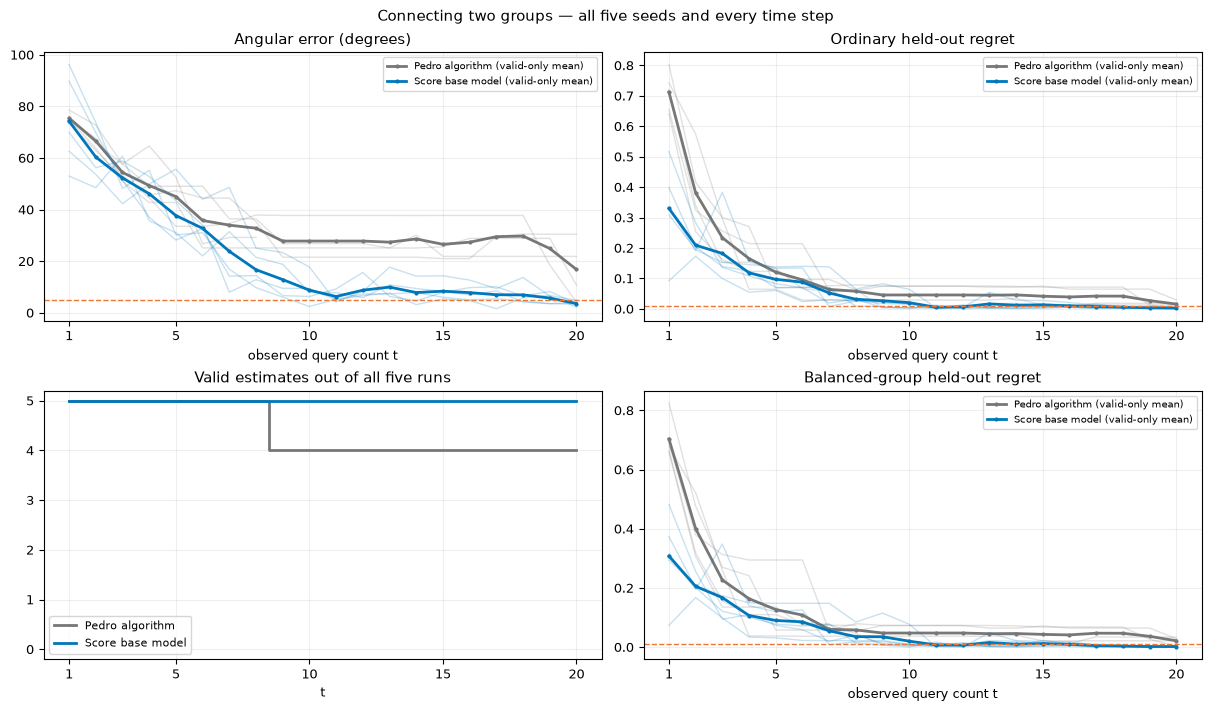

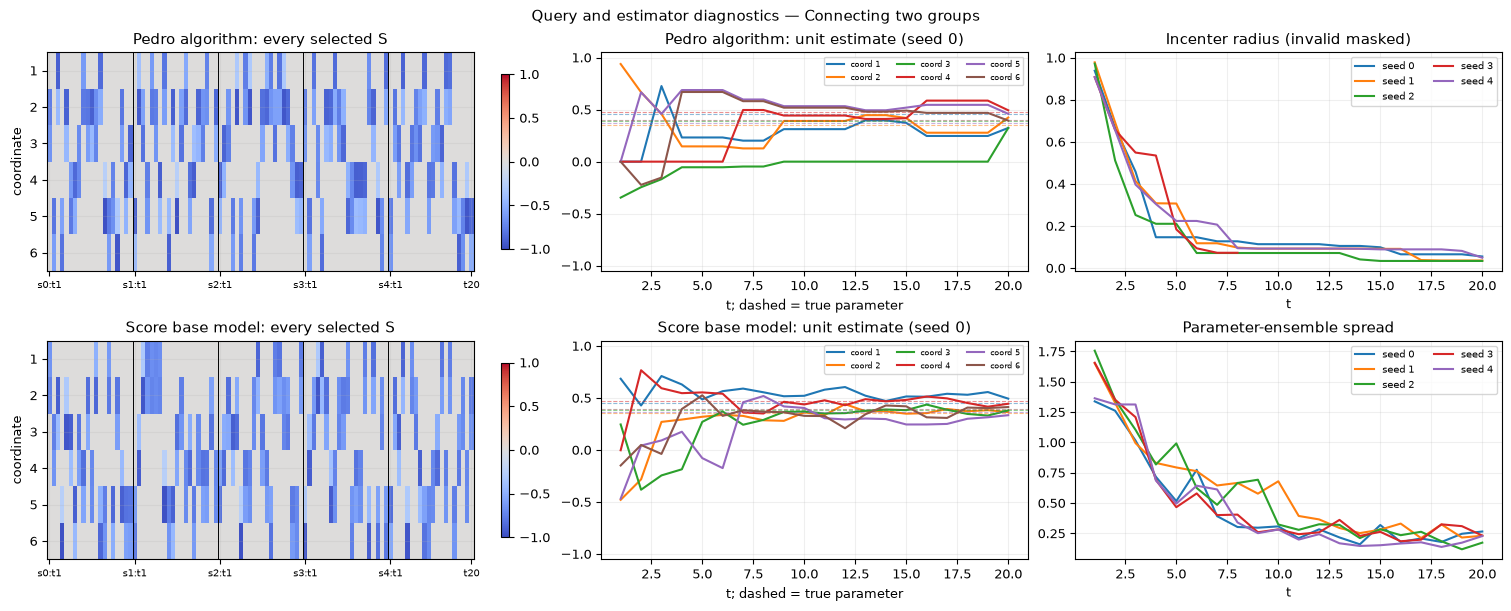

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,coordinate 1 vs 2,coordinate 2 vs 3,coordinate 4 vs 5,coordinate 5 vs 6,coordinate 3 vs 4
0,0,Pedro algorithm,valid,NaN,3,3,6,5,4,2
1,0,Score base model,valid,NaN,1,3,4,3,7,3
2,1,Pedro algorithm,valid,NaN,2,5,7,4,3,1
3,1,Score base model,valid,NaN,2,5,2,5,4,4
4,2,Pedro algorithm,valid,NaN,1,7,4,4,3,2
5,2,Score base model,valid,NaN,0,4,5,4,4,3
6,3,Pedro algorithm,degenerate_cone,9.0,1,4,6,6,3,1
7,3,Score base model,valid,NaN,2,5,5,4,5,1
8,4,Pedro algorithm,valid,NaN,0,4,4,4,4,4
9,4,Score base model,valid,NaN,2,4,4,4,5,3


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[-0.0000, 0.9384, -0.3457, -0.0000, -0.0000, -0.0000]","[0.0000, -0.7610, -0.6487, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",78.61865,0.65464,valid,None,0.68937
1,Score base model,"[0.5036, -0.3525, 0.1804, -0.0021, -0.3444, -0.1097]","[-0.6544, -0.7562, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",89.73268,0.51705,valid,None,0.48224
2,Pedro algorithm,"[-0.0000, 0.6670, -0.2457, -0.0000, 0.6670, -0.2232]","[0.0000, 0.0000, 0.0000, 0.0000, -0.7986, -0.6019]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",72.73093,0.32393,valid,None,0.37900
2,Score base model,"[0.3406, -0.2250, -0.3041, 0.6102, 0.0336, 0.0381]","[0.0000, 0.0000, -0.7572, -0.6532, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",69.79637,0.28315,valid,None,0.25586
3,Pedro algorithm,"[0.7265, 0.4583, -0.1688, -0.0000, 0.4583, -0.1534]","[-0.9026, -0.4306, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",57.68893,0.25585,valid,None,0.31335
3,Score base model,"[0.6651, 0.2526, -0.2289, 0.5556, 0.0859, -0.0355]","[0.0000, -0.9138, -0.4061, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",51.35667,0.13620,valid,None,0.09448
4,Pedro algorithm,"[0.2323, 0.1466, -0.0540, -0.0000, 0.6881, 0.6695]","[0.0000, 0.0000, 0.0000, 0.0000, -0.5798, -0.8148]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",49.05716,0.21421,valid,None,0.29445
4,Score base model,"[0.7022, 0.3260, -0.2071, 0.6090, 0.1954, 0.4392]","[0.0000, 0.0000, 0.0000, 0.0000, -0.2425, -0.9701]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",37.09130,0.10832,valid,None,0.10957
5,Pedro algorithm,"[0.2323, 0.1466, -0.0540, -0.0000, 0.6881, 0.6695]","[0.0000, -0.8961, -0.4438, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",49.05716,0.21421,valid,None,0.29445
5,Score base model,"[0.5509, 0.3615, 0.3059, 0.6268, -0.0884, 0.5956]","[0.0000, -0.3107, -0.9505, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",28.18943,0.08287,valid,None,0.07382


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[-0.0000, -0.0000, -0.0000, -0.0000, 0.9782, -0.2076]","[0.0000, 0.0000, 0.0000, 0.0000, -0.9138, -0.4061]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",73.27955,0.64099,valid,None,0.66591
1,Score base model,"[-0.0109, 0.1970, 0.2510, -0.1649, -0.1435, 0.5875]","[0.0000, 0.0000, 0.0000, 0.0000, -0.6192, -0.7853]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",62.60427,0.30918,valid,None,0.29430
2,Pedro algorithm,"[-0.1346, 0.6929, -0.0000, -0.0000, 0.6929, -0.1470]","[-0.3745, -0.9272, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",62.91057,0.25328,valid,None,0.31853
2,Score base model,"[0.0702, -0.0591, 0.0997, 0.5838, -0.0322, 0.6257]","[0.0000, 0.0000, -0.3964, -0.9181, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",53.64352,0.19465,valid,None,0.20790
3,Pedro algorithm,"[-0.0804, 0.4137, 0.8022, -0.0000, 0.4137, -0.0878]","[0.0000, -0.5798, -0.8148, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",52.43823,0.16165,valid,None,0.15586
3,Score base model,"[-0.0009, 0.4882, -0.0662, 0.5613, 0.1950, 0.6524]","[-0.3107, -0.9505, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",42.29491,0.15240,valid,None,0.17340
4,Pedro algorithm,"[-0.0599, 0.3081, 0.5973, 0.6675, 0.3081, -0.0654]","[0.0000, 0.0000, 0.0000, -0.7610, -0.6487, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",45.63577,0.12321,valid,None,0.10997
4,Score base model,"[0.5708, 0.4744, -0.1773, 0.5263, -0.2179, 0.5387]","[-0.7610, -0.6487, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",49.92687,0.14560,valid,None,0.14968
5,Pedro algorithm,"[-0.1064, 0.3069, 0.5950, 0.6649, 0.3069, -0.0651]","[-0.6192, -0.7853, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",47.33863,0.12321,valid,None,0.10997
5,Score base model,"[0.6494, 0.6554, -0.1536, 0.5125, -0.4257, 0.4197]","[-0.6858, -0.7278, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",55.65443,0.13787,valid,None,0.14813


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[-0.0000, -0.0000, -0.0000, 0.9719, -0.2355, -0.0000]","[0.0000, 0.0000, 0.0000, -0.8891, -0.4577, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",75.06113,0.74319,valid,None,0.67778
1,Score base model,"[-0.1570, 0.3158, 0.1249, 0.1817, 0.5531, -0.1033]","[0.0000, 0.0000, 0.0000, -0.5798, -0.8148, 0.0000]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",52.99075,0.09207,valid,None,0.07384
2,Pedro algorithm,"[-0.0000, -0.0000, 0.8502, 0.5116, -0.1240, -0.0000]","[0.0000, 0.0000, -0.8835, -0.4684, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",63.78175,0.57404,valid,None,0.52155
2,Score base model,"[0.1771, -0.0042, 0.0077, 0.5698, 0.5725, -0.0002]","[0.0000, 0.0000, -0.5230, -0.8523, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",48.52408,0.17300,valid,None,0.16737
3,Pedro algorithm,"[-0.0000, 0.8700, 0.4193, 0.2523, -0.0611, -0.0000]","[0.0000, -0.6544, -0.7562, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",50.95553,0.29739,valid,None,0.26033
3,Score base model,"[0.0769, 0.4727, -0.2402, 0.3352, 0.5529, -0.2952]","[0.0000, -0.8415, -0.5402, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",60.70163,0.09969,valid,None,0.09905
4,Pedro algorithm,"[-0.0000, 0.8085, 0.4212, 0.3452, 0.2105, -0.0738]","[0.0000, 0.0000, 0.0000, 0.0000, -0.7809, -0.6247]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",42.76490,0.06442,valid,None,0.03771
4,Score base model,"[-0.0148, 0.6412, 0.4515, 0.4895, 0.7204, -0.0679]","[0.0000, 0.0000, -0.9138, -0.4061, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",35.69243,0.05493,valid,None,0.03423
5,Pedro algorithm,"[-0.0000, 0.8085, 0.4212, 0.3452, 0.2105, -0.0738]","[-0.3107, -0.9505, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",42.76490,0.06442,valid,None,0.03771
5,Score base model,"[0.1772, 0.4536, 0.5030, 0.4920, 0.6706, -0.0667]","[0.0000, -0.5358, -0.8443, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",31.02636,0.06055,valid,None,0.03129


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[-0.0000, -0.4191, 0.9079, -0.0000, -0.0000, -0.0000]","[0.0000, -0.7610, -0.6487, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",75.46722,0.72027,valid,None,0.65949
1,Score base model,"[0.1055, 0.0559, 0.0473, -0.0779, -0.0661, 0.5801]","[0.0000, 0.0000, 0.0000, 0.0000, -0.3107, -0.9505]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",69.93904,0.33334,valid,None,0.31534
2,Pedro algorithm,"[-0.0000, -0.3033, 0.6572, -0.0000, 0.6572, -0.2101]","[0.0000, 0.0000, 0.0000, 0.0000, -0.8145, -0.5802]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",65.83940,0.33916,valid,None,0.30676
2,Score base model,"[0.1404, 0.1339, -0.0938, 0.4656, -0.0466, 0.3376]","[0.0000, 0.0000, -0.3964, -0.9181, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",56.24921,0.19105,valid,None,0.19550
3,Pedro algorithm,"[0.5492, -0.2535, 0.5492, -0.0000, 0.5492, -0.1756]","[-0.8145, -0.5802, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",57.66257,0.15334,valid,None,0.13534
3,Score base model,"[-0.1197, -0.2232, 0.4490, 0.4877, 0.0515, 0.3248]","[0.0000, -0.6192, -0.7853, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",58.81330,0.38315,valid,None,0.34840
4,Pedro algorithm,"[0.5351, -0.2470, 0.5351, -0.2253, 0.5351, -0.1711]","[0.0000, 0.0000, -0.6989, -0.7152, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",64.68325,0.15334,valid,None,0.13534
4,Score base model,"[-0.1222, 0.3819, 0.6256, 0.6883, -0.3371, 0.6036]","[-0.3107, -0.9505, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",52.83068,0.15815,valid,None,0.14001
5,Pedro algorithm,"[0.1840, -0.0850, 0.1840, -0.0775, 0.6958, 0.6595]","[0.0000, 0.0000, 0.0000, 0.0000, -0.5358, -0.8443]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",52.62608,0.13234,valid,None,0.13528
5,Score base model,"[0.3953, 0.4085, 0.6552, 0.7189, -0.3380, 0.5612]","[-0.9026, -0.4306, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",43.42253,0.13345,valid,None,0.11946


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[-0.0000, -0.0000, -0.0000, -0.0000, -0.4191, 0.9079]","[0.0000, 0.0000, 0.0000, 0.0000, -0.7610, -0.6487]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",74.83896,0.80259,valid,None,0.82515
1,Score base model,"[0.1141, -0.1216, -0.0517, 0.0644, 0.4836, -0.5376]","[0.0000, 0.0000, 0.0000, 0.0000, -0.8415, -0.5402]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",96.20105,0.39854,valid,None,0.37328
2,Pedro algorithm,"[-0.0000, 0.6558, -0.2195, -0.0000, -0.3027, 0.6558]","[0.0000, -0.7986, -0.6019, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",67.62932,0.41650,valid,None,0.47679
2,Score base model,"[-0.1797, 0.5610, -0.3708, 0.0737, 0.4898, 0.0670]","[0.0000, -0.8415, -0.5402, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",73.69554,0.20393,valid,None,0.20104
3,Pedro algorithm,"[-0.0000, 0.7962, 0.3970, -0.1317, -0.1832, 0.3970]","[0.0000, 0.0000, -0.8016, -0.5978, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",53.31079,0.30007,valid,None,0.27011
3,Score base model,"[0.0382, 0.6174, 0.5644, -0.1667, 0.5487, 0.0006]","[0.0000, 0.0000, -0.9138, -0.4061, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",48.17939,0.13895,valid,None,0.12124
4,Pedro algorithm,"[0.6420, 0.6105, 0.3044, -0.1010, -0.1405, 0.3044]","[-0.8961, -0.4438, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",44.58162,0.27037,valid,None,0.24107
4,Score base model,"[0.6087, 0.4562, 0.3012, -0.2651, 0.4109, -0.1739]","[-0.8891, -0.4577, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",55.24594,0.12484,valid,None,0.10056
5,Pedro algorithm,"[0.5556, 0.6171, 0.4466, 0.2240, -0.1034, 0.2240]","[0.0000, 0.0000, 0.0000, -0.8415, -0.5402, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",33.52549,0.06956,valid,None,0.05773
5,Score base model,"[0.6147, 0.6236, 0.4729, -0.1699, 0.6245, 0.4616]","[0.0000, 0.0000, 0.0000, 0.0000, -0.3107, -0.9505]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",30.19233,0.06963,valid,None,0.07810


Completed scenario 1/8; 10/80 complete runs loaded.


In [3]:
run_and_show_family(0)

## 2. Several boundaries to locate — 4D

Three equally available reference comparisons, (1,2), (1,3), (1,4), have 40 candidate ratios each. There are no deliberately rare groups. Query selection must decide which boundary needs refinement and which ratio to test.

CACHED boundaries-4d seed=0 Pedro algorithm
CACHED boundaries-4d seed=0 Score base model
CACHED boundaries-4d seed=1 Pedro algorithm
CACHED boundaries-4d seed=1 Score base model
CACHED boundaries-4d seed=2 Pedro algorithm
CACHED boundaries-4d seed=2 Score base model
CACHED boundaries-4d seed=3 Pedro algorithm
CACHED boundaries-4d seed=3 Score base model
CACHED boundaries-4d seed=4 Pedro algorithm
CACHED boundaries-4d seed=4 Score base model


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,4/5,1,10.2015,9.2091,0.0206,0.0225,2,2,0.0748
1,Score base model,ordinary,5/5,0,1.7153,0.8472,0.0004,0.0005,5,5,14.5148


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,67.7419,1.9925,0.2577,0.2893,5/5,53.3049,5.7543,0.2206,0.1497
1,2,5/5,65.6431,11.0746,0.1323,0.0249,5/5,56.2408,6.1573,0.1808,0.1890
2,3,5/5,64.9292,20.8383,0.1296,0.0196,5/5,58.2239,14.7825,0.0894,0.0118
3,4,5/5,38.7021,7.3298,0.0767,0.0194,5/5,40.1676,11.6687,0.0633,0.0249
4,5,5/5,38.7124,7.3168,0.0773,0.0189,5/5,35.9296,19.2543,0.0449,0.0321
5,6,4/5,34.2223,19.5151,0.0690,0.0392,5/5,34.6490,20.0825,0.0453,0.0314
6,7,4/5,27.7323,17.0641,0.0502,0.0390,5/5,36.3400,18.8927,0.0378,0.0258
7,8,4/5,27.7107,17.0330,0.0500,0.0385,5/5,34.7425,15.8326,0.0362,0.0220
8,9,4/5,24.2167,12.9583,0.0372,0.0160,5/5,34.6161,15.0377,0.0345,0.0237
9,10,4/5,17.8863,16.3895,0.0257,0.0220,5/5,29.4900,12.0994,0.0373,0.0279


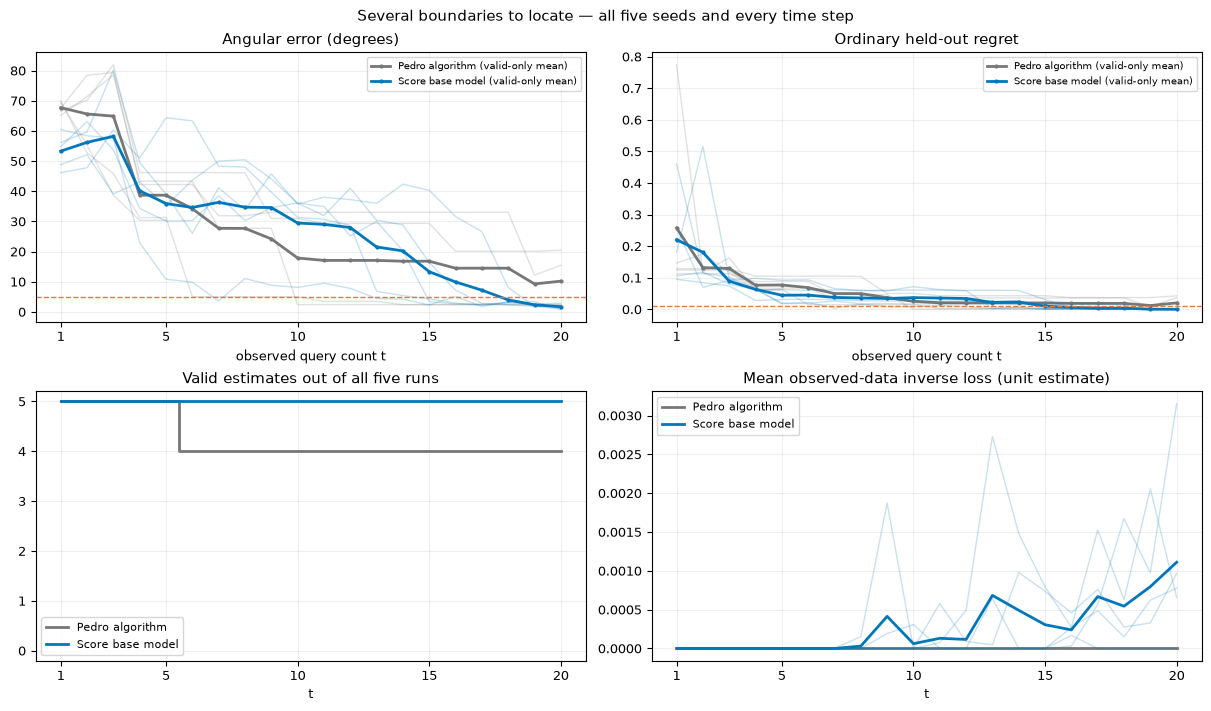

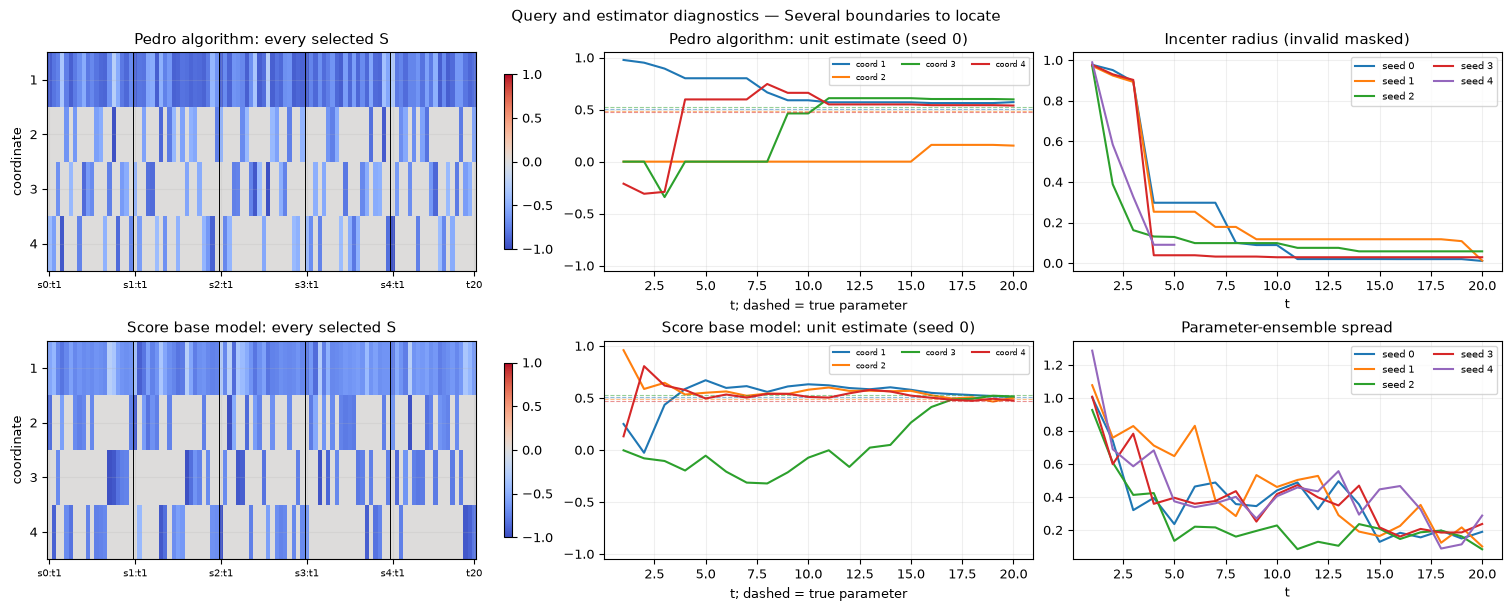

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,coordinate 1 vs 2,coordinate 1 vs 3,coordinate 1 vs 4
0,0,Pedro algorithm,valid,NaN,0,5,8,7
1,0,Score base model,valid,NaN,3,7,6,7
2,1,Pedro algorithm,valid,NaN,1,8,5,7
3,1,Score base model,valid,NaN,2,7,5,8
4,2,Pedro algorithm,valid,NaN,0,7,8,5
5,2,Score base model,valid,NaN,1,7,5,8
6,3,Pedro algorithm,valid,NaN,1,5,7,8
7,3,Score base model,valid,NaN,3,9,7,4
8,4,Pedro algorithm,degenerate_cone,6.0,3,7,8,5
9,4,Score base model,valid,NaN,4,8,8,4


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[0.9773, -0.0000, -0.0000, -0.2118]","[-0.9103, 0.0000, 0.0000, -0.4140]","[1.0000, 0.0000, 0.0000, 0.0000]",66.58336,0.12929,valid,None
1,Score base model,"[0.1453, 0.5579, -0.0018, 0.0764]","[-0.5510, -0.8345, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",48.83394,0.18088,valid,None
2,Pedro algorithm,"[0.9512, -0.0000, -0.0000, -0.3087]","[-0.8094, 0.0000, 0.0000, -0.5873]","[1.0000, 0.0000, 0.0000, 0.0000]",70.23613,0.12929,valid,None
2,Score base model,"[-0.0169, 0.3699, -0.0507, 0.5083]","[-0.4518, 0.0000, 0.0000, -0.8921]","[0.0000, 0.0000, 0.0000, 1.0000]",52.15031,0.51685,valid,None
3,Pedro algorithm,"[0.8942, -0.0000, -0.3407, -0.2902]","[-0.7465, 0.0000, -0.6654, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",82.00347,0.12929,valid,None
3,Score base model,"[0.4502, 0.6691, -0.1097, 0.6420]","[-0.7138, 0.0000, -0.7003, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",39.12498,0.09797,valid,None
4,Pedro algorithm,"[0.8015, -0.0000, -0.0000, 0.5980]","[-0.3325, 0.0000, 0.0000, -0.9431]","[0.0000, 0.0000, 0.0000, 1.0000]",46.22824,0.10527,valid,None
4,Score base model,"[0.6043, 0.5493, -0.2033, 0.5944]","[-0.8094, -0.5873, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",43.10464,0.06098,valid,None
5,Pedro algorithm,"[0.8015, -0.0000, -0.0000, 0.5980]","[-0.7610, -0.6487, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",46.22824,0.10527,valid,None
5,Score base model,"[0.6226, 0.5109, -0.0512, 0.4596]","[-0.7138, 0.0000, 0.0000, -0.7003]","[1.0000, 0.0000, 0.0000, 0.0000]",35.22395,0.06287,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[0.9719, -0.0000, -0.2355, -0.0000]","[-0.8891, 0.0000, -0.4577, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",67.56149,0.12480,valid,None
1,Score base model,"[0.0011, 0.4600, 0.2276, 0.0927]","[-0.3745, -0.9272, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",46.19452,0.25923,valid,None
2,Pedro algorithm,"[0.9242, -0.0000, -0.2240, -0.3093]","[-0.7986, 0.0000, 0.0000, -0.6019]","[1.0000, 0.0000, 0.0000, 0.0000]",78.45511,0.12480,valid,None
2,Score base model,"[0.4643, 0.5648, 0.2006, -0.1265]","[-0.9026, 0.0000, 0.0000, -0.4306]","[1.0000, 0.0000, 0.0000, 0.0000]",47.81898,0.06970,valid,None
3,Pedro algorithm,"[0.9309, -0.2270, -0.1425, -0.2483]","[-0.8194, -0.5732, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",79.39162,0.12480,valid,None
3,Score base model,"[0.4923, 0.3950, 0.0298, -0.2052]","[-0.7986, -0.6019, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",60.37210,0.09241,valid,None
4,Pedro algorithm,"[0.6679, -0.0000, 0.7443, -0.0000]","[-0.5510, 0.0000, -0.8345, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",42.23923,0.06729,valid,None
4,Score base model,"[0.4037, 0.4909, 0.0818, -0.0942]","[-0.5798, -0.8148, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",50.93885,0.09860,valid,None
5,Pedro algorithm,"[0.6679, -0.0000, 0.7443, -0.0000]","[-0.5201, 0.0000, -0.8541, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",42.23923,0.06729,valid,None
5,Score base model,"[0.6257, 0.5453, -0.0238, -0.3010]","[-0.7465, -0.6654, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",64.39230,0.09241,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[0.9706, -0.2408, -0.0000, -0.0000]","[-0.8840, -0.4675, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",69.96586,0.14697,valid,None
1,Score base model,"[-0.0611, -0.0299, 0.0824, 0.5222]","[-0.2885, 0.0000, 0.0000, -0.9575]","[0.0000, 0.0000, 0.0000, 1.0000]",60.45959,0.46101,valid,None
2,Pedro algorithm,"[0.3884, -0.0964, -0.0000, 0.9164]","[-0.6955, 0.0000, 0.0000, -0.7185]","[0.0000, 0.0000, 0.0000, 1.0000]",52.77081,0.17546,valid,None
2,Score base model,"[0.4508, 0.0517, -0.2639, 0.5931]","[-0.7138, 0.0000, -0.7003, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",58.40674,0.11493,valid,None
3,Pedro algorithm,"[0.5960, -0.0000, -0.0000, 0.8029]","[-0.8891, 0.0000, 0.0000, -0.4577]","[1.0000, 0.0000, 0.0000, 0.0000]",45.87824,0.11825,valid,None
3,Score base model,"[0.3968, 0.6535, -0.4983, 0.5982]","[-0.2425, -0.9701, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",57.64392,0.10216,valid,None
4,Pedro algorithm,"[0.4813, -0.0000, 0.5899, 0.6484]","[-0.6544, 0.0000, -0.7562, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",31.28002,0.06088,valid,None
4,Score base model,"[0.6751, 0.5124, 0.1464, 0.5981]","[-0.8530, -0.5219, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",22.92156,0.06520,valid,None
5,Pedro algorithm,"[0.4730, -0.0000, 0.6084, 0.6372]","[-0.6757, 0.0000, -0.7372, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",31.33158,0.06383,valid,None
5,Score base model,"[0.6100, 0.4981, 0.3584, 0.5428]","[-0.3325, 0.0000, -0.9431, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",10.85414,0.01974,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[0.9773, -0.0000, -0.0000, -0.2118]","[-0.9103, 0.0000, 0.0000, -0.4140]","[1.0000, 0.0000, 0.0000, 0.0000]",65.15848,0.11279,valid,None
1,Score base model,"[0.5011, 0.0941, 0.1658, -0.1484]","[-0.7745, 0.0000, 0.0000, -0.6326]","[1.0000, 0.0000, 0.0000, 0.0000]",54.84229,0.09546,valid,None
2,Pedro algorithm,"[0.9303, -0.0000, -0.0000, -0.3669]","[-0.7308, 0.0000, 0.0000, -0.6826]","[1.0000, 0.0000, 0.0000, 0.0000]",71.41974,0.11279,valid,None
2,Score base model,"[0.4321, 0.6401, -0.1135, -0.2638]","[-0.6313, -0.7755, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",63.11308,0.08473,valid,None
3,Pedro algorithm,"[0.9028, -0.0000, -0.2413, -0.3561]","[-0.8667, 0.0000, -0.4989, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",78.62835,0.11279,valid,None
3,Score base model,"[0.3466, 0.4304, -0.0263, -0.1156]","[-0.8455, -0.5340, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",53.74722,0.07436,valid,None
4,Pedro algorithm,"[0.7104, -0.0000, -0.0000, 0.7038]","[-0.6757, 0.0000, 0.0000, -0.7372]","[0.0000, 0.0000, 0.0000, 1.0000]",43.36352,0.08840,valid,None
4,Score base model,"[0.5800, 0.6569, 0.6280, -0.0839]","[-0.2885, 0.0000, -0.9575, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",34.31090,0.02824,valid,None
5,Pedro algorithm,"[0.7104, -0.0000, -0.0000, 0.7038]","[-0.8455, 0.0000, -0.5340, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",43.36352,0.08840,valid,None
5,Score base model,"[0.6804, 0.7072, 0.4149, 0.0141]","[-0.7610, -0.6487, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",30.12112,0.03144,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.1458, -0.0000, -0.0000, 0.9893]","[-0.2885, 0.0000, 0.0000, -0.9575]","[0.0000, 0.0000, 0.0000, 1.0000]",69.44048,0.77483,valid,None
1,Score base model,"[0.5656, -0.0810, 0.0836, 0.0509]","[-0.7610, -0.6487, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",56.19428,0.10620,valid,None
2,Pedro algorithm,"[0.5842, -0.0000, -0.2017, 0.7861]","[-0.7870, 0.0000, -0.6169, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",55.33388,0.11918,valid,None
2,Score base model,"[0.3930, -0.2539, 0.6810, 0.0894]","[-0.5201, 0.0000, -0.8541, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",59.71483,0.11773,valid,None
3,Pedro algorithm,"[0.3269, 0.8288, -0.1129, 0.4399]","[-0.7308, -0.6826, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",38.74431,0.16286,valid,None
3,Score base model,"[0.4598, -0.5361, 0.6043, -0.1493]","[-0.6544, 0.0000, 0.0000, -0.7562]","[1.0000, 0.0000, 0.0000, 0.0000]",80.23149,0.08000,valid,None
4,Pedro algorithm,"[0.5881, 0.7619, -0.0000, 0.2715]","[-0.8455, -0.5340, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",30.39934,0.06188,valid,None
4,Score base model,"[0.6537, 0.0564, 0.5276, -0.1601]","[-0.7610, 0.0000, -0.6487, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",49.56217,0.06347,valid,None
5,Pedro algorithm,"[0.5881, 0.7619, -0.0000, 0.2715]","[-0.7308, 0.0000, -0.6826, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",30.39934,0.06188,valid,None
5,Score base model,"[0.6657, 0.4715, 0.5723, -0.2123]","[-0.2425, -0.9701, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",39.05673,0.01796,valid,None


Completed scenario 2/8; 20/80 complete runs loaded.


In [4]:
run_and_show_family(1)

## 3. Similar queries versus varied queries — 6D

The expert chooses exactly two coordinates. Two predetermined profiles receive 48 nearby queries each; 24 other queries cover diverse directions. Clustering is independent of theta and does not guarantee identical decisions. Both natural-mixture and balanced-group tests are reported.

CACHED redundancy-6d seed=0 Pedro algorithm
CACHED redundancy-6d seed=0 Score base model
CACHED redundancy-6d seed=1 Pedro algorithm
CACHED redundancy-6d seed=1 Score base model
CACHED redundancy-6d seed=2 Pedro algorithm
CACHED redundancy-6d seed=2 Score base model
CACHED redundancy-6d seed=3 Pedro algorithm
CACHED redundancy-6d seed=3 Score base model
CACHED redundancy-6d seed=4 Pedro algorithm
CACHED redundancy-6d seed=4 Score base model


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,30.5652,8.9585,0.0188,0.0135,0,2,0.1049
1,Pedro algorithm,balanced,5/5,0,30.5652,8.9585,0.0268,0.0212,0,0,0.1049
2,Score base model,ordinary,5/5,0,5.4143,3.4256,0.0005,0.0005,2,5,14.7524
3,Score base model,balanced,5/5,0,5.4143,3.4256,0.0007,0.0008,2,5,14.7524


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,60.2299,19.1218,0.2037,0.1733,5/5,50.7692,26.1809,0.2705,0.2659
1,2,5/5,39.4635,5.0875,0.0308,0.0178,5/5,27.9308,11.3383,0.0511,0.0517
2,3,5/5,40.5479,4.0188,0.0324,0.0060,5/5,27.1682,12.2765,0.0535,0.0299
3,4,5/5,36.2469,7.6044,0.0275,0.0128,5/5,20.6217,7.1824,0.0129,0.0081
4,5,5/5,36.1673,7.3094,0.0262,0.0112,5/5,16.8699,6.5102,0.0053,0.0053
5,6,5/5,38.4456,2.6676,0.0273,0.0039,5/5,10.4442,3.6791,0.0047,0.0022
6,7,5/5,35.6736,4.5588,0.0225,0.0067,5/5,8.6093,3.5769,0.0039,0.0022
7,8,5/5,31.8564,6.7453,0.0158,0.0047,5/5,8.7824,3.4862,0.0039,0.0024
8,9,5/5,32.4366,6.8810,0.0170,0.0045,5/5,9.4436,4.4136,0.0057,0.0060
9,10,5/5,30.9351,7.7824,0.0146,0.0058,5/5,9.1328,6.0537,0.0021,0.0026


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,60.2299,19.1218,0.2359,0.1496,5/5,50.7692,26.1809,0.2680,0.2609
1,2,5/5,39.4635,5.0875,0.0464,0.0256,5/5,27.9308,11.3383,0.0510,0.0549
2,3,5/5,40.5479,4.0188,0.0444,0.0160,5/5,27.1682,12.2765,0.0571,0.0314
3,4,5/5,36.2469,7.6044,0.0381,0.0216,5/5,20.6217,7.1824,0.0180,0.0075
4,5,5/5,36.1673,7.3094,0.0340,0.0166,5/5,16.8699,6.5102,0.0100,0.0082
5,6,5/5,38.4456,2.6676,0.0372,0.0086,5/5,10.4442,3.6791,0.0039,0.0018
6,7,5/5,35.6736,4.5588,0.0302,0.0117,5/5,8.6093,3.5769,0.0048,0.0027
7,8,5/5,31.8564,6.7453,0.0221,0.0078,5/5,8.7824,3.4862,0.0039,0.0019
8,9,5/5,32.4366,6.8810,0.0235,0.0077,5/5,9.4436,4.4136,0.0058,0.0046
9,10,5/5,30.9351,7.7824,0.0224,0.0076,5/5,9.1328,6.0537,0.0043,0.0057


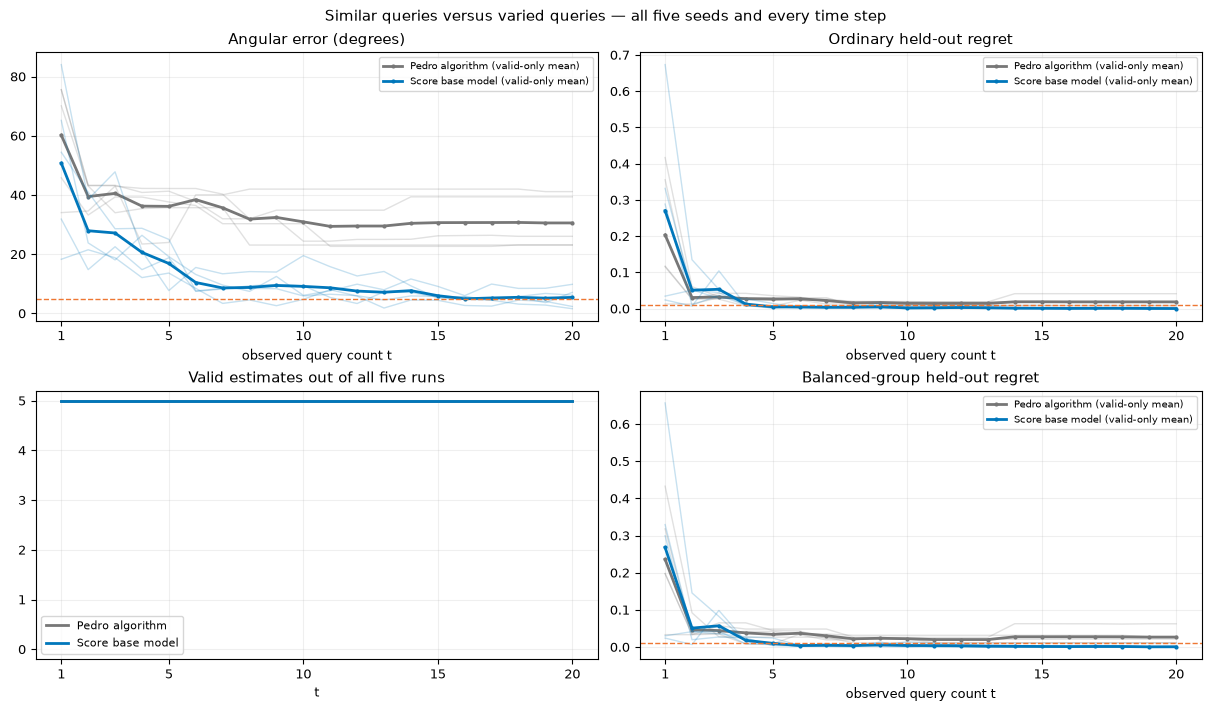

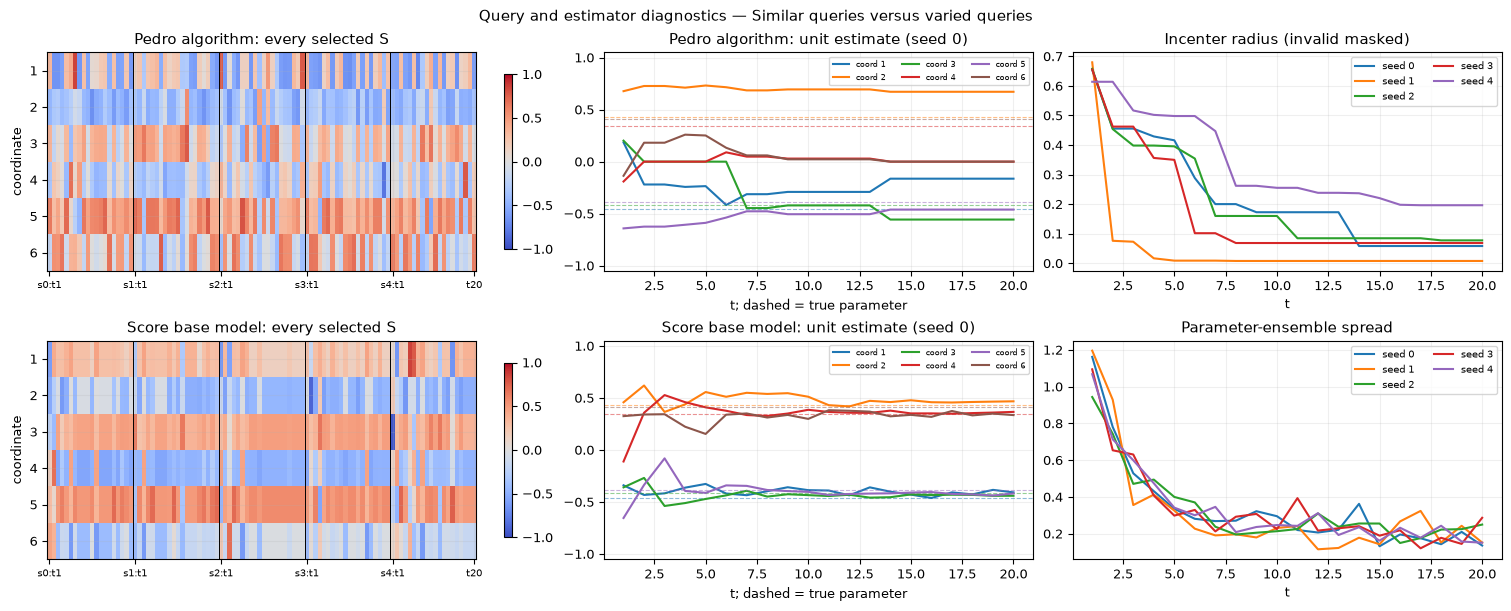

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,profile 1,profile 2,diverse
0,0,Pedro algorithm,valid,None,1,8,9,3
1,0,Score base model,valid,None,5,1,7,12
2,1,Pedro algorithm,valid,None,0,5,11,4
3,1,Score base model,valid,None,4,0,14,6
4,2,Pedro algorithm,valid,None,2,7,7,6
5,2,Score base model,valid,None,8,1,16,3
6,3,Pedro algorithm,valid,None,0,8,10,2
7,3,Score base model,valid,None,5,0,14,6
8,4,Pedro algorithm,valid,None,1,8,8,4
9,4,Score base model,valid,None,5,0,13,7


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[0.1847, 0.6774, 0.2015, -0.1908, -0.6415, -0.1359]","[0.3306, -0.4497, 0.3587, -0.3407, 0.6452, -0.1658]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",75.59069,0.11745,valid,None,0.19756
1,Score base model,"[-0.3382, 0.4564, -0.3577, -0.1103, -0.6512, 0.3240]","[-0.6045, -0.5253, -0.2212, 0.1514, 0.2919, 0.4490]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",31.86237,0.02413,valid,None,0.02403
2,Pedro algorithm,"[-0.2196, 0.7270, -0.0000, 0.0000, -0.6246, 0.1818]","[-0.6557, -0.3170, -0.1799, 0.2281, 0.2936, 0.5468]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.29710,0.02727,valid,None,0.03508
2,Score base model,"[-0.4367, 0.6258, -0.2714, 0.3613, -0.3393, 0.3444]","[0.3997, -0.2628, -0.4175, 0.6797, 0.0901, 0.3560]","[1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",14.79614,0.00705,valid,None,0.00676
3,Pedro algorithm,"[-0.2196, 0.7270, -0.0000, -0.0000, -0.6246, 0.1818]","[-0.6525, -0.2888, 0.0595, 0.1452, 0.4330, 0.5280]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.29710,0.02994,valid,None,0.03747
3,Score base model,"[-0.5013, 0.4396, -0.6473, 0.6345, -0.0971, 0.4133]","[0.2792, -0.0400, 0.4462, -0.5479, 0.5025, -0.4106]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",22.52550,0.10435,valid,None,0.09847
4,Pedro algorithm,"[-0.2428, 0.7112, -0.0000, -0.0000, -0.6067, 0.2593]","[-0.5935, -0.4073, -0.0535, 0.0353, 0.2072, 0.6594]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",40.85755,0.02994,valid,None,0.04216
4,Score base model,"[-0.4618, 0.5591, -0.6505, 0.5856, -0.5019, 0.2849]","[0.2842, -0.6182, 0.1970, -0.3040, 0.6215, -0.1398]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",14.78982,0.00931,valid,None,0.01499
5,Pedro algorithm,"[-0.2354, 0.7317, -0.0000, -0.0000, -0.5882, 0.2514]","[0.2891, -0.3520, 0.3252, -0.4265, 0.7032, -0.1020]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",41.28843,0.02994,valid,None,0.04216
5,Score base model,"[-0.4138, 0.7058, -0.5968, 0.5193, -0.5225, 0.1954]","[0.3635, -0.4941, 0.3537, -0.4764, 0.4955, -0.1618]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",18.80109,0.00258,valid,None,0.00972


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[0.0789, -0.1868, -0.6870, -0.1547, -0.6783, -0.0535]","[0.1556, -0.3222, 0.5063, -0.2670, 0.7327, -0.0867]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",70.12235,0.41690,valid,None,0.43296
1,Score base model,"[0.0333, -0.0607, -0.5984, -0.1480, -0.2453, 0.4897]","[-0.3078, -0.1377, 0.6438, -0.4188, -0.3375, -0.4272]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",54.44607,0.33183,valid,None,0.32958
2,Pedro algorithm,"[-0.0000, 0.6772, -0.6296, -0.0000, -0.3809, -0.0000]","[0.2398, -0.4419, 0.4778, -0.3288, 0.6315, -0.1096]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",43.04855,0.06075,valid,None,0.09216
2,Score base model,"[-0.1398, 0.5924, -0.5479, -0.3463, -0.4654, 0.6304]","[0.2647, -0.5424, 0.2621, -0.4462, 0.5774, -0.1859]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",40.98707,0.05208,valid,None,0.04143
3,Pedro algorithm,"[-0.0000, 0.6489, -0.6033, -0.0000, -0.3651, 0.2857]","[-0.3078, -0.1377, 0.6438, -0.4188, -0.3375, -0.4272]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",34.00346,0.03302,valid,None,0.02746
3,Score base model,"[-0.6885, 0.6138, -0.4401, -0.1182, -0.5354, 0.5822]","[0.4502, -0.0103, 0.2993, 0.4499, 0.3464, -0.6207]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",28.60212,0.02865,valid,None,0.03550
4,Pedro algorithm,"[-0.0000, 0.6421, -0.5945, -0.0000, -0.4287, 0.2246]","[0.2312, -0.5125, 0.4473, -0.1983, 0.6513, -0.1425]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",35.40915,0.03034,valid,None,0.02650
4,Score base model,"[-0.6169, 0.7503, -0.5794, -0.1693, -0.3633, 0.6297]","[0.2763, -0.4357, 0.4266, -0.4500, 0.5824, -0.1004]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",28.75824,0.02727,valid,None,0.02716
5,Pedro algorithm,"[-0.0000, 0.6303, -0.6104, -0.0000, -0.4301, 0.2125]","[0.2735, -0.4319, 0.4552, -0.2769, 0.6505, -0.1779]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",35.73323,0.03030,valid,None,0.02650
5,Score base model,"[-0.5220, 0.8088, -0.6114, -0.0781, -0.4169, 0.5651]","[0.2891, -0.3520, 0.3252, -0.4265, 0.7032, -0.1020]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",25.01432,0.01440,valid,None,0.02420


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[-0.6564, -0.0497, -0.2371, 0.2609, 0.0503, 0.6632]","[0.7658, -0.0851, -0.3308, 0.3742, 0.0874, -0.3864]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",45.80832,0.35577,valid,None,0.31816
1,Score base model,"[-0.4348, 0.3359, -0.4625, 0.4635, -0.4496, 0.1084]","[-0.6345, -0.1550, 0.2997, 0.4714, -0.4594, 0.2243]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",18.28857,0.03458,valid,None,0.03009
2,Pedro algorithm,"[-0.5088, 0.4531, -0.0347, 0.0803, -0.4532, 0.5682]","[-0.6225, -0.3669, -0.0149, 0.1287, 0.4259, 0.5288]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",33.23919,0.02651,valid,None,0.03837
2,Score base model,"[-0.3316, 0.6670, -0.7366, 0.3208, -0.2260, 0.2625]","[0.3244, -0.5851, 0.3994, -0.3954, 0.4629, -0.1493]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",21.49682,0.05114,valid,None,0.04149
3,Pedro algorithm,"[-0.4573, 0.4553, 0.0040, -0.0286, -0.4938, 0.5822]","[0.0376, -0.6535, 0.3697, -0.4209, 0.5073, -0.0183]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",39.30939,0.04227,valid,None,0.06505
3,Score base model,"[-0.3480, 0.6198, -0.7249, 0.2574, -0.2891, 0.3675]","[-0.5746, -0.1481, 0.0673, -0.0359, 0.3902, 0.6999]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",18.81030,0.04447,valid,None,0.04239
4,Pedro algorithm,"[-0.4573, 0.4553, 0.0040, -0.0286, -0.4938, 0.5822]","[-0.5055, -0.4042, -0.1765, 0.0534, 0.3046, 0.6740]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",39.30939,0.04227,valid,None,0.06505
4,Score base model,"[-0.3290, 0.6515, -0.6687, 0.6627, -0.4458, 0.4420]","[0.2891, -0.3520, 0.3252, -0.4265, 0.7032, -0.1020]","[0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",12.10027,0.00917,valid,None,0.00877
5,Pedro algorithm,"[-0.4573, 0.4732, -0.0000, 0.0041, -0.5175, 0.5469]","[-0.6309, -0.3442, -0.0956, 0.2301, 0.3294, 0.5594]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",37.64473,0.03591,valid,None,0.04465
5,Score base model,"[-0.4102, 0.6541, -0.5903, 0.5807, -0.5606, 0.2535]","[0.2763, -0.4357, 0.4266, -0.4500, 0.5824, -0.1004]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",13.63068,0.00518,valid,None,0.00649


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[0.1847, 0.6774, 0.2015, -0.1908, -0.6415, -0.1359]","[0.3306, -0.4497, 0.3587, -0.3407, 0.6452, -0.1658]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",75.57595,0.11557,valid,None,0.19778
1,Score base model,"[0.3839, 0.0047, 0.2398, 0.4415, 0.2322, 0.4986]","[0.2792, -0.0400, 0.4462, -0.5479, 0.5025, -0.4106]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000]",84.04847,0.67337,valid,None,0.65705
2,Pedro algorithm,"[-0.2005, 0.7213, -0.0000, 0.0000, -0.6224, 0.2283]","[-0.5750, -0.3101, -0.1529, 0.1678, 0.2948, 0.6594]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.13989,0.02630,valid,None,0.03332
2,Score base model,"[-0.2991, 0.4817, 0.2088, 0.6914, -0.2255, 0.7245]","[-0.1515, -0.8894, 0.2859, 0.0764, 0.3109, 0.0422]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",38.55727,0.13510,valid,None,0.14553
3,Pedro algorithm,"[-0.2005, 0.7213, -0.0000, 0.0000, -0.6224, 0.2283]","[-0.5972, -0.2669, -0.0123, 0.1948, 0.3304, 0.6518]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.13990,0.02630,valid,None,0.03476
3,Score base model,"[0.0518, 0.6034, 0.3550, 0.5975, -0.4520, 0.6912]","[0.2888, -0.5283, 0.3543, -0.2920, 0.6055, -0.2450]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",47.82598,0.05324,valid,None,0.08232
4,Pedro algorithm,"[-0.2785, 0.6511, -0.2447, 0.2667, -0.5439, 0.2678]","[-0.6345, -0.1550, 0.2997, 0.4714, -0.4594, 0.2243]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",23.43214,0.00689,valid,None,0.00827
4,Score base model,"[-0.2461, 0.6363, -0.1465, 0.6145, -0.4896, 0.7334]","[0.3835, 0.2123, 0.6592, 0.1754, -0.5472, 0.2075]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",21.06605,0.00882,valid,None,0.01509
5,Pedro algorithm,"[-0.2743, 0.6382, -0.2388, 0.2629, -0.5667, 0.2650]","[0.1392, -0.5375, 0.4046, -0.3488, 0.6362, -0.0400]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",23.97148,0.00689,valid,None,0.00827
5,Score base model,"[-0.4276, 0.7360, -0.4986, 0.5448, -0.4596, 0.7467]","[0.2547, -0.5914, 0.4878, -0.3846, 0.4378, -0.0884]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",7.72411,0.00158,valid,None,0.00560


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Pedro algorithm,"[-0.3329, 0.6132, -0.0681, 0.0332, -0.6152, 0.3590]","[-0.5478, -0.4056, -0.0854, 0.0261, 0.3553, 0.6333]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",34.05214,0.01294,valid,None,0.03328
1,Score base model,"[-0.2046, 0.3823, -0.3179, 0.2906, -0.2420, -0.5041]","[0.0751, 0.2050, -0.9444, 0.1200, -0.1957, 0.0885]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",65.20047,0.28851,valid,None,0.29948
2,Pedro algorithm,"[-0.3324, 0.6138, -0.0651, 0.0235, -0.6159, 0.3586]","[-0.5643, -0.4801, -0.0686, 0.0059, 0.4457, 0.4976]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",34.59281,0.01294,valid,None,0.03328
2,Score base model,"[-0.3982, 0.6399, -0.5175, 0.4738, -0.5621, 0.0922]","[-0.6345, -0.1550, 0.2997, 0.4714, -0.4594, 0.2243]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",23.81676,0.01006,valid,None,0.01967
3,Pedro algorithm,"[-0.1869, 0.6913, -0.0000, -0.0000, -0.6619, 0.2214]","[0.2888, -0.5283, 0.3543, -0.2920, 0.6055, -0.2450]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",42.98963,0.03037,valid,None,0.05727
3,Score base model,"[-0.3366, 0.3785, -0.3059, 0.7140, -0.5487, 0.2519]","[0.2289, -0.2938, 0.4071, -0.4103, 0.7246, 0.0472]","[0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",18.07727,0.03671,valid,None,0.02704
4,Pedro algorithm,"[-0.2084, 0.6862, -0.0000, -0.0000, -0.6558, 0.2359]","[-0.5755, -0.3482, -0.1301, 0.0540, 0.3220, 0.6512]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",42.22612,0.02790,valid,None,0.04837
4,Score base model,"[-0.3827, 0.6064, -0.4344, 0.7085, -0.7805, 0.0411]","[0.1791, -0.6333, 0.4771, -0.2821, 0.4866, -0.1515]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",26.39424,0.00969,valid,None,0.02409
5,Pedro algorithm,"[-0.2160, 0.6859, -0.0000, -0.0000, -0.6550, 0.2319]","[-0.6262, -0.3104, -0.1538, 0.2702, 0.4226, 0.4861]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",42.19850,0.02790,valid,None,0.04837
5,Score base model,"[-0.3145, 0.6865, -0.3448, 0.7572, -0.6792, 0.2539]","[0.8552, -0.0826, 0.2411, 0.0934, -0.2404, 0.3703]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",19.17927,0.00257,valid,None,0.00397


Completed scenario 3/8; 30/80 complete runs loaded.


In [5]:
run_and_show_family(2)

## 4. Ordinary balanced choice — 4D

The expert chooses one coordinate. Candidate queries are uniformly distributed unit directions. This is an ordinary control without deliberately rare or redundant query groups.

CACHED balanced-choice-4d seed=0 Pedro algorithm
CACHED balanced-choice-4d seed=0 Score base model
CACHED balanced-choice-4d seed=1 Pedro algorithm
CACHED balanced-choice-4d seed=1 Score base model
CACHED balanced-choice-4d seed=2 Pedro algorithm
CACHED balanced-choice-4d seed=2 Score base model
CACHED balanced-choice-4d seed=3 Pedro algorithm
CACHED balanced-choice-4d seed=3 Score base model
CACHED balanced-choice-4d seed=4 Pedro algorithm
CACHED balanced-choice-4d seed=4 Score base model


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,10.6737,6.1094,0.0101,0.0095,0,3,0.0807
1,Score base model,ordinary,5/5,0,2.0080,0.8352,0.0004,0.0005,5,5,14.2379


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,52.3440,16.4912,0.2249,0.2183,5/5,59.6548,17.6088,0.3039,0.2079
1,2,5/5,34.9566,11.6538,0.0786,0.0863,5/5,52.3316,17.3387,0.2565,0.1670
2,3,5/5,33.1702,13.0894,0.0960,0.0742,5/5,22.9724,15.8865,0.0780,0.0858
3,4,5/5,30.1906,13.9127,0.0912,0.0783,5/5,13.0147,4.7723,0.0125,0.0060
4,5,5/5,31.7544,13.6805,0.1054,0.0811,5/5,8.7967,2.5775,0.0084,0.0043
5,6,5/5,30.8596,13.9472,0.0969,0.0717,5/5,7.0595,2.3384,0.0042,0.0021
6,7,5/5,26.1551,15.0253,0.0812,0.0815,5/5,7.8296,3.0054,0.0062,0.0044
7,8,5/5,24.5413,16.4363,0.0766,0.0867,5/5,6.3929,1.9714,0.0038,0.0012
8,9,5/5,12.9436,5.3149,0.0122,0.0105,5/5,6.2606,3.6876,0.0041,0.0043
9,10,5/5,13.1615,5.2084,0.0126,0.0102,5/5,5.7404,2.5969,0.0028,0.0019


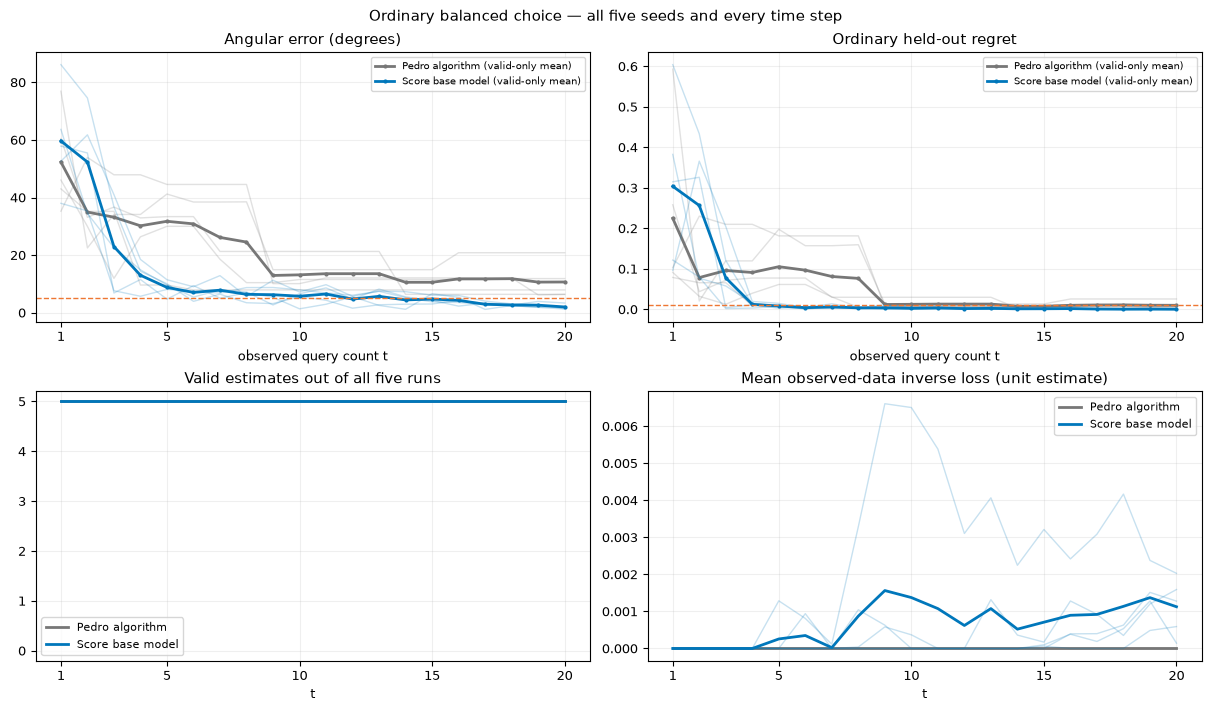

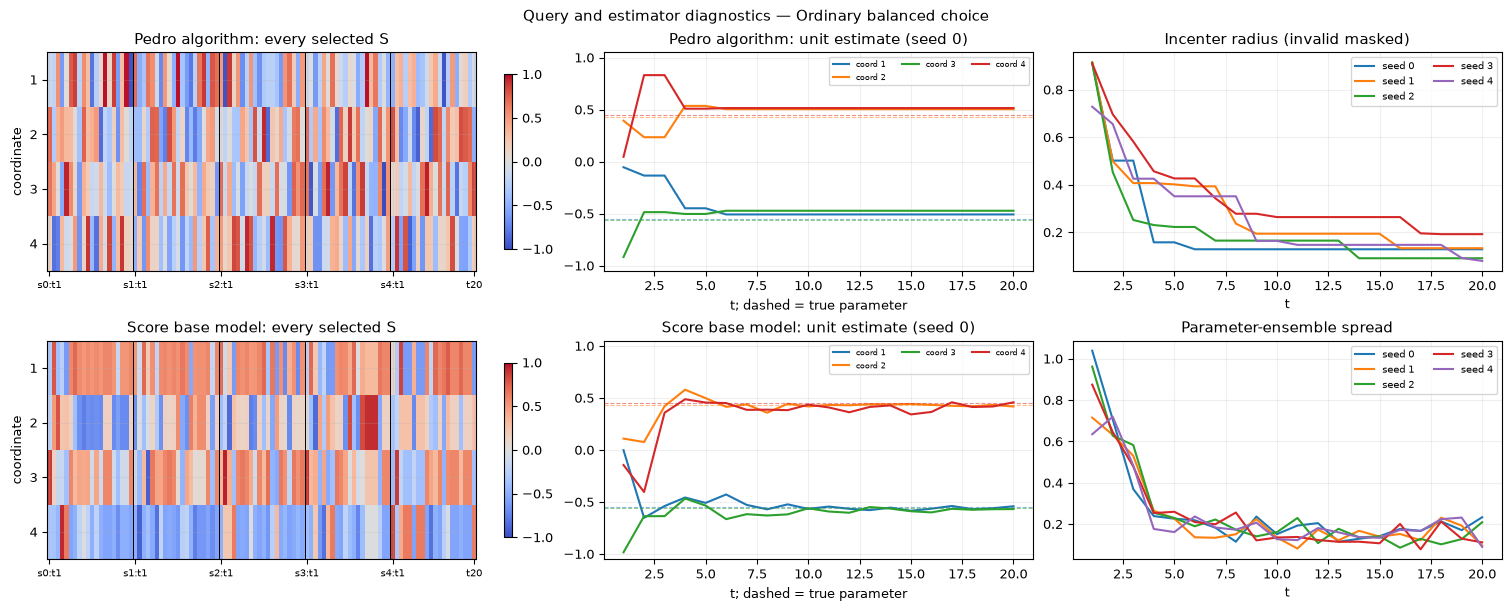

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,None,0,20
1,0,Score base model,valid,None,2,20
2,1,Pedro algorithm,valid,None,0,20
3,1,Score base model,valid,None,3,20
4,2,Pedro algorithm,valid,None,0,20
5,2,Score base model,valid,None,3,20
6,3,Pedro algorithm,valid,None,0,20
7,3,Score base model,valid,None,1,20
8,4,Pedro algorithm,valid,None,0,20
9,4,Score base model,valid,None,5,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Score base model,"[-0.0012, 0.0561, -0.5049, -0.0743]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",57.86244,0.31490,valid,None
2,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
2,Score base model,"[-0.5286, 0.0620, -0.5161, -0.3273]","[0.7870, 0.4912, 0.1455, -0.3439]","[1.0000, 0.0000, 0.0000, 0.0000]",55.47425,0.32613,valid,None
3,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[0.5341, 0.3739, 0.0193, -0.7580]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
3,Score base model,"[-0.5002, 0.3908, -0.5900, 0.3322]","[-0.3759, 0.7957, -0.1522, -0.4498]","[0.0000, 0.0000, 0.0000, 1.0000]",6.84773,0.00433,valid,None
4,Pedro algorithm,"[-0.4483, 0.5357, -0.5028, 0.5091]","[-0.6183, 0.4833, -0.5262, 0.3275]","[0.0000, 0.0000, 0.0000, 1.0000]",9.62537,0.00893,valid,None
4,Score base model,"[-0.4247, 0.5384, -0.4339, 0.4532]","[-0.2421, 0.2384, -0.1360, 0.9306]","[0.0000, 0.0000, 1.0000, 0.0000]",11.53961,0.01146,valid,None
5,Pedro algorithm,"[-0.4483, 0.5357, -0.5028, 0.5091]","[0.0178, 0.3209, 0.9417, -0.0999]","[0.0000, 0.0000, 1.0000, 0.0000]",9.62537,0.00893,valid,None
5,Score base model,"[-0.6067, 0.5939, -0.6374, 0.5437]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",4.71212,0.00286,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Score base model,"[0.0756, 0.5560, -0.1425, -0.1004]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",63.66072,0.38259,valid,None
2,Pedro algorithm,"[-0.7957, 0.4237, -0.3355, 0.2735]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",22.51927,0.02074,valid,None
2,Score base model,"[-0.0106, 0.6560, -0.2947, 0.4854]","[-0.0988, -0.0372, -0.4371, -0.8932]","[0.0000, 0.0000, 0.0000, 1.0000]",34.46721,0.07708,valid,None
3,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[-0.3454, 0.1053, 0.6798, -0.6383]","[0.0000, 0.0000, 1.0000, 0.0000]",34.13039,0.11974,valid,None
3,Score base model,"[-0.6166, 0.6141, -0.1269, 0.5282]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",22.61123,0.05787,valid,None
4,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[0.6604, -0.2836, -0.4151, 0.5579]","[1.0000, 0.0000, 0.0000, 0.0000]",34.13039,0.11974,valid,None
4,Score base model,"[-0.6115, 0.6918, -0.2960, 0.5440]","[0.1983, -0.0246, -0.9049, -0.3758]","[0.0000, 0.0000, 0.0000, 1.0000]",14.89967,0.01545,valid,None
5,Pedro algorithm,"[-0.7384, 0.5237, -0.3876, -0.1741]","[0.5532, 0.7364, 0.3663, 0.1327]","[1.0000, 0.0000, 0.0000, 0.0000]",41.21977,0.19768,valid,None
5,Score base model,"[-0.5750, 0.6649, -0.6906, 0.4269]","[0.5427, 0.1197, 0.6454, -0.5241]","[0.0000, 0.0000, 1.0000, 0.0000]",9.64106,0.00805,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Score base model,"[-0.5578, -0.2865, 0.0487, -0.0538]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",86.15365,0.60416,valid,None
2,Pedro algorithm,"[-0.3673, 0.4471, -0.8076, 0.1135]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",33.12903,0.04375,valid,None
2,Score base model,"[-0.6272, -0.1229, -0.3114, -0.2712]","[-0.1004, -0.1892, 0.9506, 0.2248]","[0.0000, 0.0000, 1.0000, 0.0000]",74.59635,0.43358,valid,None
3,Pedro algorithm,"[-0.6235, 0.2288, -0.7401, 0.1055]","[0.8838, -0.0047, 0.4124, 0.2210]","[1.0000, 0.0000, 0.0000, 0.0000]",36.68532,0.07180,valid,None
3,Score base model,"[-0.7110, 0.5199, -0.4560, 0.0235]","[0.2157, -0.8624, 0.3946, 0.2325]","[0.0000, 1.0000, 0.0000, 0.0000]",36.73096,0.12080,valid,None
4,Pedro algorithm,"[-0.5704, 0.4600, -0.6772, 0.0669]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",32.92656,0.07742,valid,None
4,Score base model,"[-0.6902, 0.5535, -0.5851, 0.4607]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",14.40239,0.01251,valid,None
5,Pedro algorithm,"[-0.5794, 0.4548, -0.6736, 0.0603]","[0.5139, -0.3504, -0.0424, 0.7819]","[1.0000, 0.0000, 0.0000, 0.0000]",33.37335,0.07742,valid,None
5,Score base model,"[-0.5957, 0.4402, -0.4461, 0.6956]","[0.5794, 0.1426, 0.5792, -0.5554]","[0.0000, 0.0000, 0.0000, 1.0000]",10.05845,0.00879,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Score base model,"[-0.0515, 0.0890, -0.6106, 0.0477]","[-0.2201, 0.0172, 0.9032, -0.3680]","[0.0000, 0.0000, 1.0000, 0.0000]",52.60040,0.09599,valid,None
2,Pedro algorithm,"[-0.1337, 0.6943, -0.6835, 0.1814]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",29.99334,0.03234,valid,None
2,Score base model,"[-0.6571, 0.1131, -0.5177, -0.3340]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",61.77641,0.36594,valid,None
3,Pedro algorithm,"[-0.2664, 0.5778, -0.5424, 0.5486]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",11.93554,0.01270,valid,None
3,Score base model,"[-0.5743, 0.5377, -0.4879, -0.1658]","[0.2157, -0.8624, 0.3946, 0.2325]","[0.0000, 1.0000, 0.0000, 0.0000]",41.01490,0.20466,valid,None
4,Pedro algorithm,"[-0.0977, 0.4553, -0.4465, 0.7641]","[-0.2237, -0.3547, -0.6248, -0.6586]","[0.0000, 0.0000, 0.0000, 1.0000]",26.36832,0.03982,valid,None
4,Score base model,"[-0.5873, 0.5982, -0.6035, 0.2342]","[-0.4439, 0.4436, -0.4654, -0.6242]","[0.0000, 0.0000, 0.0000, 1.0000]",18.51227,0.01965,valid,None
5,Pedro algorithm,"[-0.0142, 0.4265, -0.5547, 0.7143]","[0.4336, 0.5653, 0.6917, -0.1181]","[0.0000, 0.0000, 1.0000, 0.0000]",30.00601,0.06154,valid,None
5,Score base model,"[-0.6997, 0.5912, -0.4518, 0.4893]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",11.46358,0.01496,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Score base model,"[0.0611, 0.5142, -0.0831, 0.4168]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",37.99676,0.12178,valid,None
2,Pedro algorithm,"[-0.4874, 0.5105, 0.4492, 0.5478]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",53.94416,0.23011,valid,None
2,Score base model,"[0.1325, 0.5305, -0.5166, 0.4185]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",35.34367,0.07978,valid,None
3,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[0.3767, -0.7055, -0.1865, -0.5706]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None
3,Score base model,"[-0.3871, 0.6617, -0.5966, 0.4835]","[0.8498, 0.2669, -0.1901, 0.4128]","[1.0000, 0.0000, 0.0000, 0.0000]",7.65710,0.00212,valid,None
4,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[-0.2593, -0.5307, -0.0934, 0.8015]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None
4,Score base model,"[-0.4697, 0.6191, -0.4120, 0.5937]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 0.0000, 1.0000, 0.0000]",5.71945,0.00326,valid,None
5,Pedro algorithm,"[-0.2503, 0.8171, 0.2570, 0.4513]","[0.2912, -0.1064, 0.3235, -0.8940]","[0.0000, 0.0000, 0.0000, 1.0000]",44.54726,0.18147,valid,None
5,Score base model,"[-0.5268, 0.5276, -0.3853, 0.5024]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",8.10838,0.00720,valid,None


Completed scenario 4/8; 40/80 complete runs loaded.


In [6]:
run_and_show_family(3)

## 5. Ordinary subset selection — 6D

The expert chooses exactly three of six coordinates. Dense random unit queries expose multiple comparisons in each response. Pedro may be competitive because individual responses contain several constraints.

CACHED balanced-subset-6d seed=0 Pedro algorithm
CACHED balanced-subset-6d seed=0 Score base model
CACHED balanced-subset-6d seed=1 Pedro algorithm
CACHED balanced-subset-6d seed=1 Score base model
CACHED balanced-subset-6d seed=2 Pedro algorithm
CACHED balanced-subset-6d seed=2 Score base model
CACHED balanced-subset-6d seed=3 Pedro algorithm
CACHED balanced-subset-6d seed=3 Score base model
CACHED balanced-subset-6d seed=4 Pedro algorithm
CACHED balanced-subset-6d seed=4 Score base model


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,9.0364,3.6632,0.0017,0.0009,1,5,0.1067
1,Score base model,ordinary,5/5,0,3.2693,1.3491,0.0003,0.0002,4,5,14.3105


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,29.1895,11.4187,0.1030,0.0918,5/5,32.5051,13.0781,0.0986,0.0669
1,2,5/5,22.5166,16.3656,0.0694,0.0899,5/5,21.4641,5.7050,0.0192,0.0181
2,3,5/5,17.7221,4.3351,0.0205,0.0164,5/5,14.7390,5.8529,0.0130,0.0186
3,4,5/5,15.8064,5.3438,0.0106,0.0099,5/5,9.8395,3.7777,0.0022,0.0013
4,5,5/5,17.1254,7.7130,0.0233,0.0353,5/5,8.4144,1.9347,0.0016,0.0010
5,6,5/5,16.1230,8.7794,0.0234,0.0352,5/5,9.3018,2.3255,0.0024,0.0027
6,7,5/5,16.3723,6.8693,0.0201,0.0357,5/5,6.9871,3.0490,0.0010,0.0009
7,8,5/5,16.2973,7.0142,0.0205,0.0355,5/5,6.4305,1.7316,0.0008,0.0006
8,9,5/5,15.9370,7.1991,0.0203,0.0356,5/5,7.5609,2.7867,0.0013,0.0008
9,10,5/5,14.7114,5.7386,0.0112,0.0171,5/5,5.6640,1.9885,0.0007,0.0006


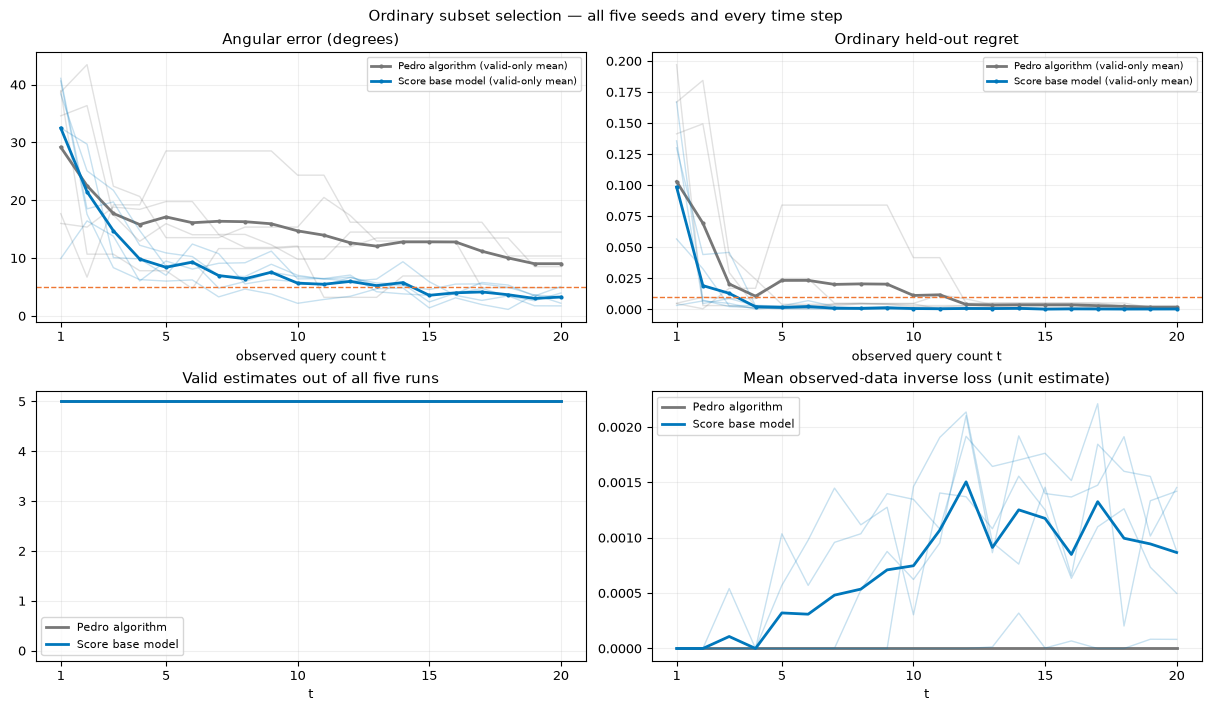

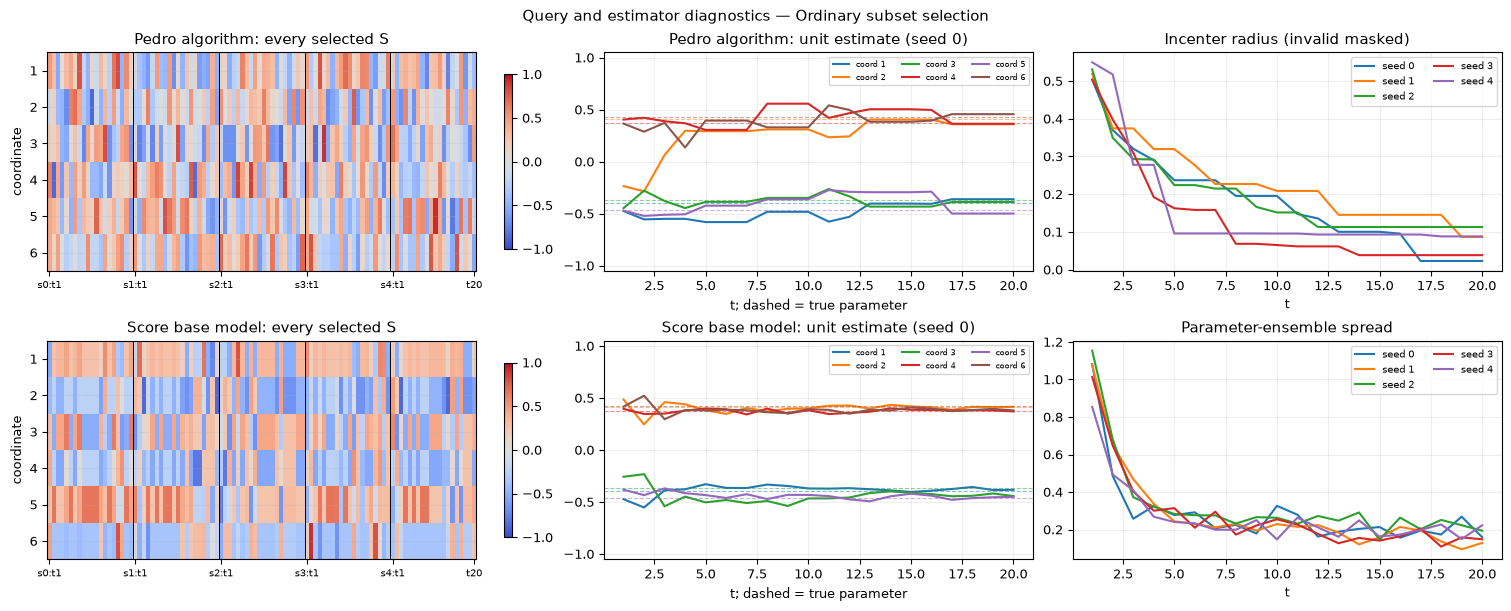

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,None,1,20
1,0,Score base model,valid,None,3,20
2,1,Pedro algorithm,valid,None,0,20
3,1,Score base model,valid,None,3,20
4,2,Pedro algorithm,valid,None,0,20
5,2,Score base model,valid,None,5,20
6,3,Pedro algorithm,valid,None,1,20
7,3,Score base model,valid,None,0,20
8,4,Pedro algorithm,valid,None,0,20
9,4,Score base model,valid,None,1,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4749, -0.2355, -0.4470, 0.4045, -0.4711, 0.3656]","[0.4868, -0.0707, 0.1619, 0.6236, 0.4170, 0.4113]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",38.70216,0.16688,valid,None
1,Score base model,"[-0.4615, 0.4727, -0.2512, 0.3850, -0.3719, 0.4067]","[-0.5381, -0.4182, 0.2741, 0.4204, 0.2564, 0.4669]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",9.91975,0.00318,valid,None
2,Pedro algorithm,"[-0.5550, -0.2857, -0.2788, 0.4217, -0.5216, 0.2878]","[0.2878, 0.1423, 0.1452, -0.8669, 0.3395, 0.0956]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",43.45378,0.18441,valid,None
2,Score base model,"[-0.6093, 0.2706, -0.2562, 0.3818, -0.4788, 0.5751]","[0.2657, -0.2217, -0.5201, -0.2323, 0.6584, -0.3497]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 1.0000]",16.43845,0.00681,valid,None
3,Pedro algorithm,"[-0.5499, 0.0642, -0.3780, 0.3885, -0.5105, 0.3730]","[-0.5381, -0.4182, 0.2741, 0.4204, 0.2564, 0.4669]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",22.42656,0.04377,valid,None
3,Score base model,"[-0.5252, 0.6239, -0.7346, 0.4743, -0.5007, 0.4010]","[0.3323, -0.4745, 0.4374, -0.5426, 0.2453, -0.3442]","[0.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.0000]",13.80065,0.00488,valid,None
4,Pedro algorithm,"[-0.5497, 0.2971, -0.4461, 0.3686, -0.5061, 0.1359]","[0.0322, -0.4601, -0.4701, -0.6214, -0.4238, -0.0235]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",20.66109,0.02426,valid,None
4,Score base model,"[-0.5551, 0.6453, -0.6584, 0.5559, -0.6098, 0.5644]","[0.3323, -0.4745, 0.4374, -0.5426, 0.2453, -0.3442]","[0.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.0000]",6.04769,0.00028,valid,None
5,Pedro algorithm,"[-0.5809, 0.2923, -0.3864, 0.3051, -0.4231, 0.3945]","[0.3109, -0.6945, -0.5379, 0.2404, 0.0876, -0.2574]","[1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",13.53944,0.00412,valid,None
5,Score base model,"[-0.4697, 0.5453, -0.7195, 0.5692, -0.6190, 0.5447]","[0.4395, -0.2131, 0.6381, 0.0459, 0.4340, -0.4048]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 1.0000]",9.48976,0.00169,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.5191, 0.4221, 0.1126, 0.5191, -0.0292, 0.5190]","[-0.0544, -0.2606, -0.0247, 0.8153, 0.0058, 0.5136]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",38.96063,0.19710,valid,None
1,Score base model,"[-0.2097, 0.3983, -0.4556, 0.4526, -0.4363, -0.2271]","[-0.1103, 0.3090, -0.6819, -0.1729, 0.6296, 0.0326]","[0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 1.0000]",38.38701,0.13012,valid,None
2,Pedro algorithm,"[-0.5830, 0.2609, -0.3786, 0.3862, -0.3808, 0.3932]","[-0.3543, -0.2921, -0.7413, 0.0079, -0.4889, -0.0242]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 1.0000]",10.68327,0.00309,valid,None
2,Score base model,"[-0.6376, 0.6264, -0.5033, 0.0414, -0.4548, 0.4101]","[0.7029, 0.2120, -0.2625, 0.1524, -0.3528, -0.4944]","[1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000]",25.08581,0.04417,valid,None
3,Pedro algorithm,"[-0.5830, 0.2609, -0.3786, 0.3862, -0.3808, 0.3932]","[-0.4619, 0.0369, -0.5768, -0.1654, 0.5684, -0.3196]","[0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 1.0000]",10.68327,0.00309,valid,None
3,Score base model,"[-0.5262, 0.6947, -0.6026, 0.5064, -0.4047, 0.0367]","[0.1099, -0.8598, 0.0783, -0.4367, 0.1479, -0.1732]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",21.72912,0.04592,valid,None
4,Pedro algorithm,"[-0.4984, 0.4051, -0.3251, 0.5116, -0.3279, 0.3356]","[-0.6111, 0.6118, -0.0615, 0.2982, 0.3738, 0.1406]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 1.0000]",7.81887,0.00102,valid,None
4,Score base model,"[-0.7885, 0.5059, -0.4234, 0.3423, -0.5495, 0.3910]","[0.2504, -0.1244, 0.1121, -0.2450, 0.6491, -0.6542]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 1.0000]",14.77575,0.00289,valid,None
5,Pedro algorithm,"[-0.4984, 0.4051, -0.3251, 0.5116, -0.3279, 0.3356]","[-0.1487, -0.3128, -0.7255, 0.4710, 0.3288, -0.1541]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000]",7.81887,0.00102,valid,None
5,Score base model,"[-0.6480, 0.6816, -0.6607, 0.5084, -0.4519, 0.4343]","[0.3323, -0.4745, 0.4374, -0.5426, 0.2453, -0.3442]","[0.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.0000]",8.62087,0.00071,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.2014, 0.5043, -0.5047, 0.3860, -0.2042, 0.5097]","[0.0910, 0.5392, -0.1342, -0.3845, 0.0937, 0.7255]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",15.99982,0.00495,valid,None
1,Score base model,"[-0.5322, 0.3687, -0.0262, 0.1674, -0.4412, 0.4255]","[-0.1862, 0.0779, -0.0195, -0.2709, -0.7837, -0.5208]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",32.51425,0.05671,valid,None
2,Pedro algorithm,"[-0.1692, 0.3259, -0.4453, 0.5952, -0.4506, 0.3310]","[0.1272, -0.0199, -0.6734, 0.2976, -0.6417, 0.1721]","[1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",15.36681,0.00981,valid,None
2,Score base model,"[-0.0967, 0.5209, -0.0734, 0.2933, -0.5320, 0.5576]","[-0.2282, 0.3678, 0.2173, -0.7928, -0.2183, 0.2986]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",29.70848,0.03269,valid,None
3,Pedro algorithm,"[-0.4907, 0.2333, -0.4353, 0.5630, -0.3700, 0.2478]","[-0.5069, 0.2077, -0.6667, 0.3925, -0.0940, 0.3043]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000]",18.82323,0.00878,valid,None
3,Score base model,"[-0.3759, 0.4958, -0.5522, 0.4889, -0.4549, 0.3788]","[-0.5069, 0.2077, -0.6667, 0.3925, -0.0940, 0.3043]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000]",10.09273,0.00287,valid,None
4,Pedro algorithm,"[-0.4888, 0.2482, -0.4337, 0.5609, -0.3686, 0.2469]","[-0.2338, -0.2463, -0.6680, -0.6415, 0.1565, 0.0495]","[0.0000, 1.0000, 0.0000, 1.0000, 1.0000, 0.0000]",18.42966,0.00878,valid,None
4,Score base model,"[-0.3141, 0.3172, -0.6158, 0.6109, -0.3881, 0.5218]","[0.3323, -0.4745, 0.4374, -0.5426, 0.2453, -0.3442]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",9.85900,0.00326,valid,None
5,Pedro algorithm,"[-0.4266, 0.4500, -0.3750, 0.4917, -0.4510, 0.1724]","[-0.1565, 0.3306, 0.0249, 0.8512, -0.3292, 0.1808]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",19.78066,0.02488,valid,None
5,Score base model,"[-0.4547, 0.3928, -0.6075, 0.7124, -0.6042, 0.6013]","[0.7957, 0.4232, -0.1281, 0.1491, -0.3335, -0.1944]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",7.03279,0.00269,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4749, -0.2355, -0.4470, 0.4045, -0.4711, 0.3656]","[0.4868, -0.0707, 0.1619, 0.6236, 0.4170, 0.4113]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",34.59952,0.14137,valid,None
1,Score base model,"[-0.2918, 0.3487, -0.3895, -0.2304, -0.3892, 0.3822]","[0.5618, -0.4615, -0.4734, 0.0908, -0.4733, 0.1225]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",41.08581,0.13571,valid,None
2,Pedro algorithm,"[-0.5106, -0.2545, -0.3230, 0.4983, -0.3604, 0.4381]","[-0.3079, 0.2743, 0.2743, 0.3411, -0.0839, 0.7945]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",36.37055,0.14940,valid,None
2,Score base model,"[-0.4490, 0.5770, -0.3408, 0.2067, -0.4083, 0.5603]","[0.1413, -0.1705, 0.1118, 0.3332, 0.0564, 0.9079]","[1.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",18.51593,0.00469,valid,None
3,Pedro algorithm,"[-0.4898, 0.0832, -0.3750, 0.4651, -0.5121, 0.3661]","[0.0119, -0.1282, -0.8291, -0.4851, -0.0668, 0.2373]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",17.46622,0.02970,valid,None
3,Score base model,"[-0.3163, 0.6098, -0.6801, 0.4461, -0.2809, 0.4217]","[0.3323, -0.4745, 0.4374, -0.5426, 0.2453, -0.3442]","[0.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.0000]",19.72425,0.00882,valid,None
4,Pedro algorithm,"[-0.5290, 0.3047, -0.3429, 0.5481, -0.3377, 0.3086]","[0.7957, 0.4232, -0.1281, 0.1491, -0.3335, -0.1944]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",12.91127,0.00218,valid,None
4,Score base model,"[-0.5534, 0.6435, -0.6241, 0.4344, -0.4929, 0.3993]","[0.2504, -0.1244, 0.1121, -0.2450, 0.6491, -0.6542]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 1.0000]",12.22924,0.00298,valid,None
5,Pedro algorithm,"[-0.4476, 0.2578, -0.2902, 0.4638, -0.5917, 0.2895]","[0.0702, 0.3360, 0.8988, 0.0107, 0.0830, -0.2596]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 1.0000]",15.95770,0.00265,valid,None
5,Score base model,"[-0.5818, 0.6239, -0.7243, 0.5375, -0.4600, 0.4599]","[0.3323, -0.4745, 0.4374, -0.5426, 0.2453, -0.3442]","[0.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.0000]",10.89941,0.00242,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.2749, 0.4942, -0.3798, 0.4833, -0.4826, 0.2634]","[0.1354, 0.4888, 0.6906, 0.3256, -0.3457, -0.2008]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",17.68523,0.00464,valid,None
1,Score base model,"[0.1744, 0.5419, -0.4676, 0.2922, -0.5035, 0.3596]","[0.1443, 0.4707, 0.5816, -0.2089, -0.5073, -0.3440]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",40.61852,0.16702,valid,None
2,Pedro algorithm,"[-0.3899, 0.4314, -0.4204, 0.3983, -0.4030, 0.4052]","[-0.4618, -0.4941, 0.4240, 0.1279, 0.1988, 0.5541]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",6.70879,0.00050,valid,None
2,Score base model,"[-0.4549, 0.2229, -0.6359, 0.6203, -0.3402, 0.2874]","[-0.5069, 0.2077, -0.6667, 0.3925, -0.0940, 0.3043]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000]",17.57172,0.00743,valid,None
3,Pedro algorithm,"[-0.6032, 0.3943, -0.2588, 0.4807, -0.3995, 0.1519]","[0.2995, -0.6610, -0.2110, -0.4302, -0.3496, -0.3487]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",19.21108,0.01699,valid,None
3,Score base model,"[-0.5140, 0.4838, -0.5651, 0.6434, -0.3973, 0.5681]","[0.1099, -0.8598, 0.0783, -0.4367, 0.1479, -0.1732]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 1.0000]",8.34820,0.00225,valid,None
4,Pedro algorithm,"[-0.6032, 0.3943, -0.2588, 0.4807, -0.3995, 0.1519]","[0.3698, 0.5893, -0.2422, -0.2525, 0.6263, -0.0375]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",19.21108,0.01699,valid,None
4,Score base model,"[-0.6162, 0.4695, -0.6068, 0.6958, -0.5176, 0.5471]","[0.2657, -0.2217, -0.5201, -0.2323, 0.6584, -0.3497]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 1.0000]",6.28586,0.00134,valid,None
5,Pedro algorithm,"[-0.6440, 0.3336, -0.0000, 0.4694, -0.2673, 0.4269]","[0.2657, -0.2217, -0.5201, -0.2323, 0.6584, -0.3497]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 1.0000]",28.53051,0.08398,valid,None
5,Score base model,"[-0.6549, 0.6691, -0.6719, 0.6941, -0.4858, 0.5477]","[0.3323, -0.4745, 0.4374, -0.5426, 0.2453, -0.3442]","[0.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.0000]",6.02909,0.00043,valid,None


Completed scenario 5/8; 50/80 complete runs loaded.


In [7]:
run_and_show_family(4)

## 6. Small budget-constrained selection — 6D

The expert chooses a feasible binary bundle with weights [1,2,2,3,3,4] and capacity 6. Queries are dense random unit directions. All 64 binary vectors can be checked exactly; feasible-set enumeration accelerates repeated MIN solves without approximating the objective.

CACHED knapsack-6d seed=0 Pedro algorithm
CACHED knapsack-6d seed=0 Score base model
CACHED knapsack-6d seed=1 Pedro algorithm
CACHED knapsack-6d seed=1 Score base model
CACHED knapsack-6d seed=2 Pedro algorithm
CACHED knapsack-6d seed=2 Score base model
CACHED knapsack-6d seed=3 Pedro algorithm
CACHED knapsack-6d seed=3 Score base model
CACHED knapsack-6d seed=4 Pedro algorithm


CACHED knapsack-6d seed=4 Score base model


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,16.2536,4.2130,0.0105,0.0098,0,3,0.1670
1,Score base model,ordinary,5/5,0,5.4924,2.4464,0.0005,0.0002,2,5,13.1566


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,29.6388,13.0998,0.0946,0.0914,5/5,39.0266,18.4181,0.1551,0.1113
1,2,5/5,23.2104,4.7000,0.0326,0.0186,5/5,25.7328,10.5918,0.0683,0.0762
2,3,5/5,28.2300,6.6939,0.0375,0.0183,5/5,16.1972,5.5216,0.0149,0.0110
3,4,5/5,27.0686,8.6348,0.0509,0.0326,5/5,13.4643,3.2361,0.0066,0.0045
4,5,5/5,26.3379,4.5366,0.0421,0.0266,5/5,11.0854,3.4478,0.0036,0.0027
5,6,5/5,25.7371,4.4087,0.0381,0.0278,5/5,8.6697,2.0537,0.0022,0.0018
6,7,5/5,23.9800,3.5802,0.0295,0.0253,5/5,8.8238,2.9061,0.0017,0.0009
7,8,5/5,20.9338,5.5535,0.0184,0.0110,5/5,8.5823,3.7152,0.0025,0.0025
8,9,5/5,21.2673,5.4366,0.0185,0.0109,5/5,8.3169,4.0437,0.0024,0.0031
9,10,5/5,19.6779,6.5880,0.0148,0.0067,5/5,7.2510,2.9548,0.0019,0.0015


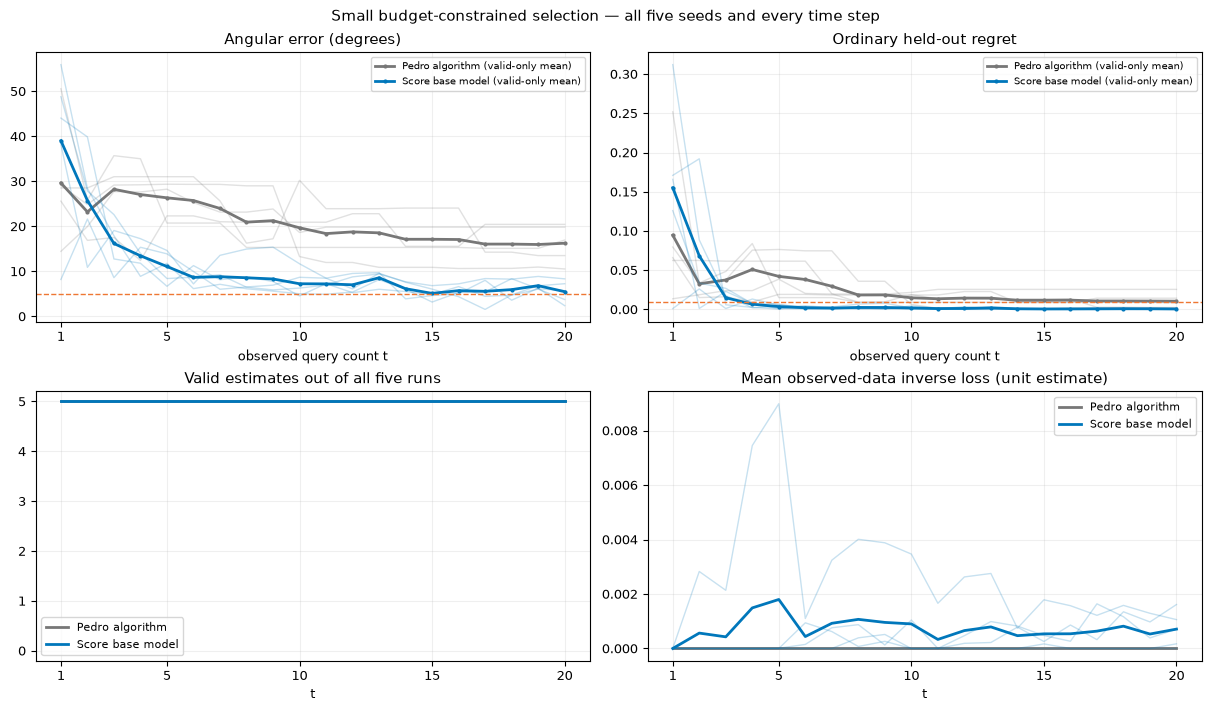

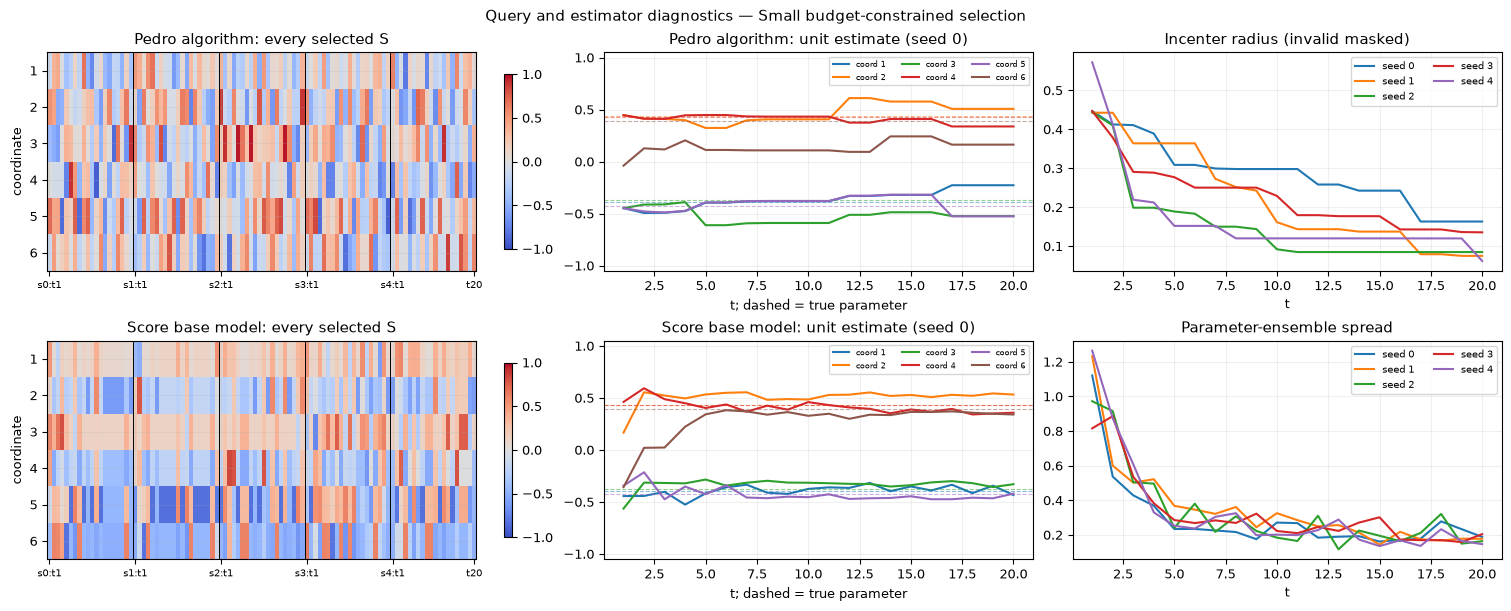

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,None,0,20
1,0,Score base model,valid,None,4,20
2,1,Pedro algorithm,valid,None,2,20
3,1,Score base model,valid,None,1,20
4,2,Pedro algorithm,valid,None,0,20
5,2,Score base model,valid,None,1,20
6,3,Pedro algorithm,valid,None,0,20
7,3,Score base model,valid,None,1,20
8,4,Pedro algorithm,valid,None,2,20
9,4,Score base model,valid,None,0,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4469, 0.4469, -0.4469, 0.4469, -0.4469, -0.0385]","[-0.1102, 0.5382, -0.4209, 0.0034, 0.7112, -0.1234]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",25.59461,0.06595,valid,None
1,Score base model,"[-0.3734, 0.1404, -0.4744, 0.3893, -0.2892, -0.3008]","[0.5143, 0.1165, 0.6046, 0.4603, -0.0952, -0.3680]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",48.78012,0.12592,valid,None
2,Pedro algorithm,"[-0.4934, 0.4127, -0.4127, 0.4127, -0.4788, 0.1279]","[0.3527, 0.4482, -0.5092, -0.0633, 0.4243, 0.4811]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",16.88796,0.01506,valid,None
2,Score base model,"[-0.5036, 0.6330, -0.3577, 0.6763, -0.2445, 0.0235]","[0.0441, -0.3337, 0.3742, -0.5283, 0.3181, 0.6054]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",27.84323,0.03355,valid,None
3,Pedro algorithm,"[-0.4912, 0.4108, -0.4108, 0.4108, -0.4885, 0.1169]","[0.4074, -0.5178, -0.5997, -0.0774, 0.4446, 0.0508]","[1.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",17.53054,0.01615,valid,None
3,Score base model,"[-0.5605, 0.7297, -0.4422, 0.6805, -0.6609, 0.0328]","[-0.2053, -0.1891, 0.6676, -0.2083, 0.2903, 0.5905]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",22.61519,0.02685,valid,None
4,Pedro algorithm,"[-0.4754, 0.3989, -0.3892, 0.4453, -0.4725, 0.2047]","[-0.0327, -0.4786, 0.0118, -0.0870, -0.8574, 0.1644]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",12.42540,0.00948,valid,None
4,Score base model,"[-0.7290, 0.6880, -0.4454, 0.6241, -0.4880, 0.3107]","[0.1472, 0.3234, 0.8092, -0.0740, 0.0692, 0.4568]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",13.98829,0.00752,valid,None
5,Pedro algorithm,"[-0.3942, 0.3239, -0.6108, 0.4482, -0.3914, 0.1122]","[-0.3648, 0.2101, 0.3744, -0.7416, 0.2354, 0.2778]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",22.32277,0.01912,valid,None
5,Score base model,"[-0.5831, 0.7457, -0.3974, 0.5637, -0.5929, 0.4784]","[0.0861, -0.2582, 0.2938, -0.3760, 0.1759, -0.8169]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",8.41214,0.00103,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4427, 0.4427, -0.4427, 0.4427, -0.4427, -0.1421]","[0.5143, 0.1165, 0.6046, 0.4603, -0.0952, -0.3680]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",28.53286,0.06237,valid,None
1,Score base model,"[-0.3502, -0.0311, -0.4783, 0.0227, -0.2714, 0.5307]","[-0.4280, 0.1618, 0.2003, 0.0942, -0.6821, -0.5258]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",38.19394,0.16576,valid,None
2,Pedro algorithm,"[-0.4427, 0.4427, -0.4427, 0.4427, -0.4427, -0.1421]","[0.3844, -0.5743, -0.2790, -0.0082, -0.6223, -0.2394]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",28.53286,0.06237,valid,None
2,Score base model,"[-0.5572, 0.5189, -0.4771, 0.3726, -0.3966, 0.3727]","[-0.5010, 0.7815, 0.1242, 0.3151, 0.0961, -0.1192]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",10.89327,0.00121,valid,None
3,Pedro algorithm,"[-0.6561, 0.3641, -0.3641, 0.3641, -0.4016, -0.1021]","[0.0680, 0.6307, -0.1362, -0.0424, 0.7364, 0.1870]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",31.02642,0.06149,valid,None
3,Score base model,"[-0.5803, 0.3157, -0.6412, 0.1732, -0.6786, 0.6176]","[0.0861, -0.2582, 0.2938, -0.3760, 0.1759, -0.8169]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",19.08015,0.02291,valid,None
4,Pedro algorithm,"[-0.6561, 0.3641, -0.3641, 0.3641, -0.4016, -0.1021]","[0.5492, 0.0001, 0.5366, -0.3932, -0.2400, -0.4452]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",31.02642,0.06149,valid,None
4,Score base model,"[-0.4079, 0.3590, -0.6888, 0.6319, -0.3395, 0.5936]","[0.0441, -0.3337, 0.3742, -0.5283, 0.3181, 0.6054]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",17.26532,0.00774,valid,None
5,Pedro algorithm,"[-0.6561, 0.3641, -0.3641, 0.3641, -0.4016, -0.1021]","[0.6730, 0.1527, 0.3722, 0.2420, 0.5715, -0.0043]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",31.02642,0.06149,valid,None
5,Score base model,"[-0.3790, 0.3663, -0.6278, 0.4877, -0.4077, 0.6280]","[0.1261, -0.1753, 0.1322, -0.2072, -0.8323, -0.4476]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",14.64931,0.00653,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4442, 0.4430, -0.4442, 0.4381, -0.4442, 0.1410]","[0.3535, 0.8920, 0.1771, 0.1735, 0.0024, 0.1338]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",14.44420,0.01354,valid,None
1,Score base model,"[0.0387, 0.5155, -0.0380, -0.1821, -0.4098, 0.4759]","[0.1261, -0.1753, 0.1322, -0.2072, -0.8323, -0.4476]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",55.91600,0.31201,valid,None
2,Pedro algorithm,"[-0.4099, 0.5358, -0.4571, 0.4042, -0.4099, 0.0676]","[-0.3569, -0.1371, 0.9077, 0.1369, -0.0536, -0.0905]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",19.96088,0.01865,valid,None
2,Score base model,"[-0.3731, 0.3743, -0.4795, -0.0119, -0.6501, 0.4992]","[0.3955, -0.2278, 0.2477, 0.2860, 0.5658, -0.5731]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",28.44079,0.08863,valid,None
3,Pedro algorithm,"[-0.1990, 0.4939, -0.6991, 0.1962, -0.1990, 0.3868]","[0.0861, -0.2582, 0.2938, -0.3760, 0.1759, -0.8169]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",27.72455,0.02393,valid,None
3,Score base model,"[-0.4431, 0.4186, -0.4633, 0.2002, -0.6607, 0.4436]","[0.2450, -0.1411, 0.1208, 0.8409, 0.2827, 0.3442]","[1.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",17.92596,0.01757,valid,None
4,Pedro algorithm,"[-0.1989, 0.4937, -0.6987, 0.1989, -0.1989, 0.3866]","[-0.5359, 0.5915, 0.0040, -0.5758, -0.1063, 0.1416]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",27.64409,0.02393,valid,None
4,Score base model,"[-0.6280, 0.4660, -0.5117, 0.4216, -0.6191, 0.3954]","[0.2525, 0.2138, 0.2435, 0.7976, -0.3521, -0.2668]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",8.89766,0.00211,valid,None
5,Pedro algorithm,"[-0.1891, 0.4981, -0.6897, 0.1891, -0.1891, 0.4110]","[-0.2263, -0.0268, 0.9676, -0.0322, -0.0811, -0.0648]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",28.25149,0.03849,valid,None
5,Score base model,"[-0.5465, 0.5795, -0.5987, 0.3505, -0.7008, 0.5173]","[0.1261, -0.1753, 0.1322, -0.2072, -0.8323, -0.4476]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",11.78384,0.00416,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4469, 0.4469, -0.4469, 0.4469, -0.4469, -0.0385]","[-0.1102, 0.5382, -0.4209, 0.0034, 0.7112, -0.1234]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",29.06389,0.07952,valid,None
1,Score base model,"[-0.4642, 0.4094, -0.3731, 0.3783, -0.3736, 0.5220]","[0.5127, 0.2525, -0.3459, -0.1321, -0.3121, 0.6624]","[1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",8.19463,0.00102,valid,None
2,Pedro algorithm,"[-0.3792, 0.5511, -0.3792, 0.3792, -0.5140, 0.0281]","[-0.0044, -0.4775, 0.1828, 0.1446, 0.5918, 0.6062]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",24.85022,0.03319,valid,None
2,Score base model,"[-0.2543, 0.4317, -0.1932, 0.2193, -0.2293, 0.6255]","[0.1261, -0.1753, 0.1322, -0.2072, -0.8323, -0.4476]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",21.61831,0.02609,valid,None
3,Pedro algorithm,"[-0.2907, 0.5284, -0.5672, 0.2907, -0.4795, 0.0000]","[0.1830, -0.1960, 0.4203, 0.0812, 0.8356, -0.2158]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",29.16873,0.03762,valid,None
3,Score base model,"[-0.4117, 0.5112, -0.2883, 0.4623, -0.5231, 0.6069]","[0.1169, -0.0196, -0.7141, 0.4314, 0.5363, -0.0468]","[1.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",8.60452,0.00112,valid,None
4,Pedro algorithm,"[-0.2889, 0.5250, -0.5636, 0.3102, -0.4764, -0.0059]","[-0.1852, -0.0960, 0.0169, -0.4518, -0.8468, -0.1870]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",29.23251,0.07552,valid,None
4,Score base model,"[-0.4962, 0.7211, -0.3903, 0.1695, -0.6349, 0.4996]","[0.3955, -0.2278, 0.2477, 0.2860, 0.5658, -0.5731]","[1.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",15.35743,0.01322,valid,None
5,Pedro algorithm,"[-0.2772, 0.5499, -0.5623, 0.2990, -0.4638, -0.0025]","[0.4691, -0.2005, 0.4019, 0.2960, 0.1030, 0.6929]","[1.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",29.35769,0.07641,valid,None
5,Score base model,"[-0.5649, 0.6955, -0.2133, 0.5600, -0.4724, 0.5385]","[0.0441, -0.3337, 0.3742, -0.5283, 0.3181, 0.6054]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",13.89303,0.00558,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.5720, -0.1249, -0.5720, 0.5720, -0.0520, -0.0000]","[0.6230, -0.0215, 0.0468, -0.7638, -0.1400, -0.0790]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",50.55842,0.25184,valid,None
1,Score base model,"[0.0238, 0.6073, -0.0934, 0.0209, -0.1890, 0.6607]","[0.0810, -0.6130, 0.1309, -0.3950, -0.4459, -0.4956]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",44.04833,0.17084,valid,None
2,Pedro algorithm,"[-0.4125, 0.3310, -0.6055, 0.4219, -0.4125, 0.0745]","[-0.4613, 0.2757, 0.0390, 0.2964, 0.7387, 0.2759]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",25.82010,0.03378,valid,None
2,Score base model,"[-0.4858, 0.5369, 0.2504, 0.2959, -0.3379, 0.6695]","[0.5454, -0.0072, 0.0480, 0.2591, -0.7900, -0.0953]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",39.86845,0.19197,valid,None
3,Pedro algorithm,"[-0.2194, 0.4611, -0.4528, 0.6960, -0.2194, 0.0396]","[-0.0546, -0.6435, 0.3093, -0.3481, -0.6039, -0.0363]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",35.69980,0.04837,valid,None
3,Score base model,"[-0.4819, 0.5155, -0.2857, 0.3136, -0.5772, 0.6281]","[0.5783, -0.1039, -0.2727, 0.7472, 0.1172, -0.0915]","[1.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",12.75995,0.00590,valid,None
4,Pedro algorithm,"[-0.2123, 0.4462, -0.4382, 0.6735, -0.3320, -0.0000]","[-0.7832, -0.5427, 0.0413, 0.2542, 0.1604, 0.0030]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",35.01455,0.08391,valid,None
4,Score base model,"[-0.4496, 0.2864, -0.5813, 0.4575, -0.3830, 0.6258]","[0.0441, -0.3337, 0.3742, -0.5283, 0.3181, 0.6054]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",11.81258,0.00255,valid,None
5,Pedro algorithm,"[-0.1522, 0.4846, -0.3896, 0.5499, -0.2575, 0.4706]","[0.1261, -0.1753, 0.1322, -0.2072, -0.8323, -0.4476]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",20.73096,0.01501,valid,None
5,Score base model,"[-0.6754, 0.5000, -0.5698, 0.5470, -0.5311, 0.6597]","[0.3844, -0.5743, -0.2790, -0.0082, -0.6223, -0.2394]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",6.68885,0.00049,valid,None


Completed scenario 6/8; 60/80 complete runs loaded.


In [8]:
run_and_show_family(5)

## 7. Stronger parameter noise — 4D

The geometry, hidden parameters and test queries match scenario 4. Only parameter-noise sigma changes from 0.02 to 0.08. This isolates sensitivity to noisier decisions.

CACHED strong-noise-4d seed=0 Pedro algorithm
CACHED strong-noise-4d seed=0 Score base model
CACHED strong-noise-4d seed=1 Pedro algorithm
CACHED strong-noise-4d seed=1 Score base model
CACHED strong-noise-4d seed=2 Pedro algorithm
CACHED strong-noise-4d seed=2 Score base model
CACHED strong-noise-4d seed=3 Pedro algorithm
CACHED strong-noise-4d seed=3 Score base model
CACHED strong-noise-4d seed=4 Pedro algorithm
CACHED strong-noise-4d seed=4 Score base model


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,15.3198,6.3055,0.0177,0.0107,0,1,0.1165
1,Score base model,ordinary,5/5,0,5.1850,2.9120,0.0020,0.0014,3,5,18.5229


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,52.3440,16.4912,0.2249,0.2183,5/5,59.6548,17.6088,0.3039,0.2079
1,2,5/5,34.9566,11.6538,0.0786,0.0863,5/5,52.3316,17.3387,0.2565,0.1670
2,3,5/5,33.1702,13.0894,0.0960,0.0742,5/5,22.9724,15.8865,0.0780,0.0858
3,4,5/5,34.9626,7.8790,0.1017,0.0673,5/5,15.6791,6.9602,0.0208,0.0189
4,5,5/5,36.5264,6.0841,0.1159,0.0678,5/5,11.0841,3.6539,0.0129,0.0066
5,6,5/5,35.5348,5.9771,0.1104,0.0548,5/5,9.0208,2.8816,0.0062,0.0024
6,7,5/5,30.8303,11.0429,0.0948,0.0709,5/5,10.0113,3.5328,0.0090,0.0059
7,8,5/5,29.2165,13.6088,0.0901,0.0779,5/5,8.8806,2.5006,0.0066,0.0038
8,9,5/5,17.6187,8.8797,0.0257,0.0290,5/5,9.1152,1.7243,0.0073,0.0038
9,10,5/5,17.8367,8.6707,0.0261,0.0287,5/5,7.5983,2.4593,0.0043,0.0024


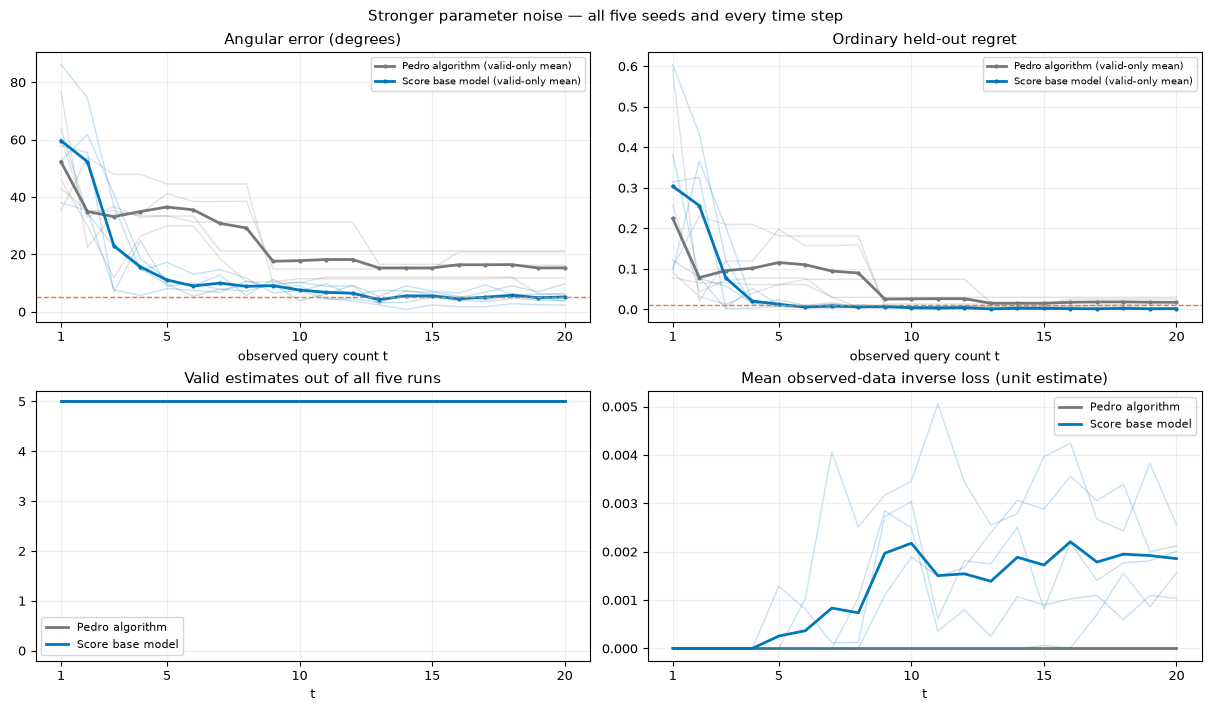

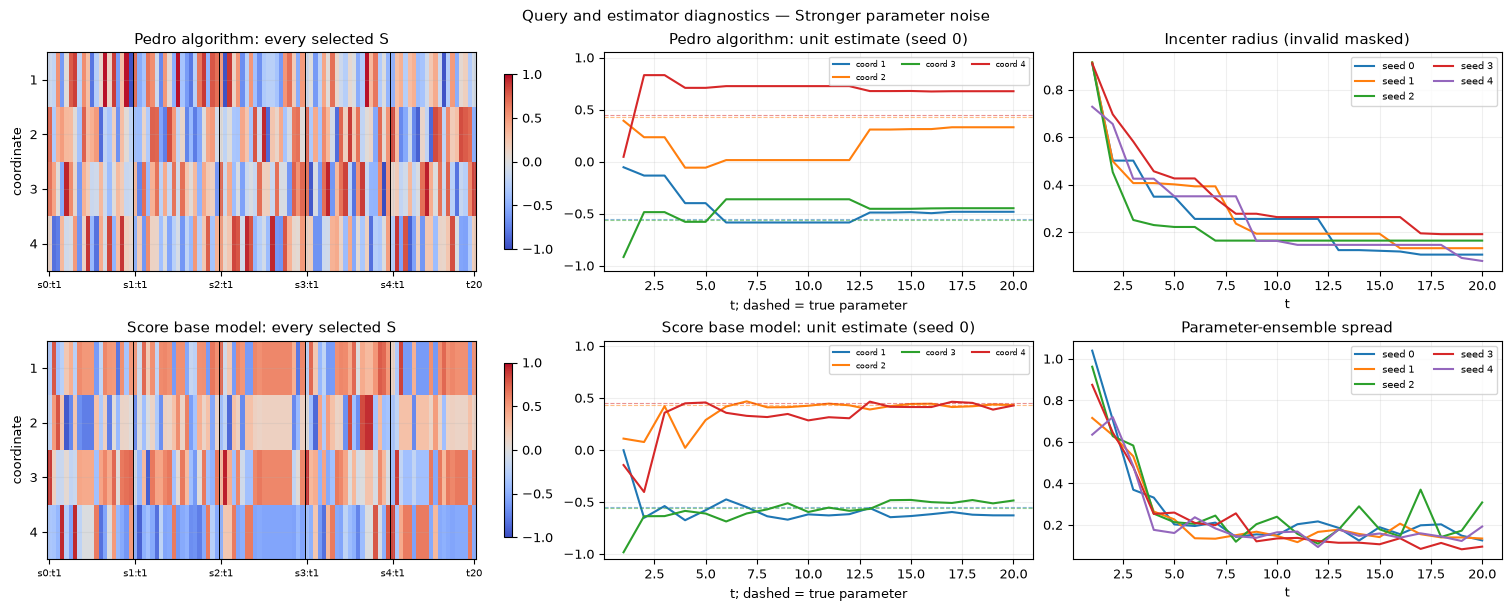

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,None,1,20
1,0,Score base model,valid,None,4,20
2,1,Pedro algorithm,valid,None,0,20
3,1,Score base model,valid,None,3,20
4,2,Pedro algorithm,valid,None,1,20
5,2,Score base model,valid,None,3,20
6,3,Pedro algorithm,valid,None,0,20
7,3,Score base model,valid,None,5,20
8,4,Pedro algorithm,valid,None,0,20
9,4,Score base model,valid,None,7,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Score base model,"[-0.0012, 0.0561, -0.5049, -0.0743]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",57.86244,0.31490,valid,None
2,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
2,Score base model,"[-0.5286, 0.0620, -0.5161, -0.3273]","[0.7870, 0.4912, 0.1455, -0.3439]","[1.0000, 0.0000, 0.0000, 0.0000]",55.47425,0.32613,valid,None
3,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[0.5341, 0.3739, 0.0193, -0.7580]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
3,Score base model,"[-0.5002, 0.3908, -0.5900, 0.3322]","[-0.3759, 0.7957, -0.1522, -0.4498]","[0.0000, 0.0000, 0.0000, 1.0000]",6.84773,0.00433,valid,None
4,Pedro algorithm,"[-0.3989, -0.0578, -0.5784, 0.7092]","[-0.6183, 0.4833, -0.5262, 0.3275]","[0.0000, 1.0000, 0.0000, 0.0000]",33.48563,0.06129,valid,None
4,Score base model,"[-0.6294, 0.0191, -0.5460, 0.4178]","[-0.2421, 0.2384, -0.1360, 0.9306]","[0.0000, 1.0000, 0.0000, 0.0000]",24.86171,0.05289,valid,None
5,Pedro algorithm,"[-0.3989, -0.0578, -0.5784, 0.7092]","[0.0178, 0.3209, 0.9417, -0.0999]","[0.0000, 0.0000, 1.0000, 0.0000]",33.48563,0.06129,valid,None
5,Score base model,"[-0.5499, 0.2734, -0.5803, 0.4338]","[0.2258, -0.9353, 0.0572, -0.2665]","[0.0000, 1.0000, 0.0000, 0.0000]",8.97070,0.01096,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Score base model,"[0.0756, 0.5560, -0.1425, -0.1004]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",63.66072,0.38259,valid,None
2,Pedro algorithm,"[-0.7957, 0.4237, -0.3355, 0.2735]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",22.51927,0.02074,valid,None
2,Score base model,"[-0.0106, 0.6560, -0.2947, 0.4854]","[-0.0988, -0.0372, -0.4371, -0.8932]","[0.0000, 0.0000, 0.0000, 1.0000]",34.46721,0.07708,valid,None
3,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[-0.3454, 0.1053, 0.6798, -0.6383]","[0.0000, 0.0000, 1.0000, 0.0000]",34.13039,0.11974,valid,None
3,Score base model,"[-0.6166, 0.6141, -0.1269, 0.5282]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",22.61123,0.05787,valid,None
4,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[0.6604, -0.2836, -0.4151, 0.5579]","[1.0000, 0.0000, 0.0000, 0.0000]",34.13039,0.11974,valid,None
4,Score base model,"[-0.6115, 0.6918, -0.2960, 0.5440]","[0.1983, -0.0246, -0.9049, -0.3758]","[0.0000, 0.0000, 0.0000, 1.0000]",14.89967,0.01545,valid,None
5,Pedro algorithm,"[-0.7384, 0.5237, -0.3876, -0.1741]","[0.5532, 0.7364, 0.3663, 0.1327]","[1.0000, 0.0000, 0.0000, 0.0000]",41.21977,0.19768,valid,None
5,Score base model,"[-0.5750, 0.6649, -0.6906, 0.4269]","[0.5427, 0.1197, 0.6454, -0.5241]","[0.0000, 0.0000, 1.0000, 0.0000]",9.64106,0.00805,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Score base model,"[-0.5578, -0.2865, 0.0487, -0.0538]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",86.15365,0.60416,valid,None
2,Pedro algorithm,"[-0.3673, 0.4471, -0.8076, 0.1135]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",33.12903,0.04375,valid,None
2,Score base model,"[-0.6272, -0.1229, -0.3114, -0.2712]","[-0.1004, -0.1892, 0.9506, 0.2248]","[0.0000, 0.0000, 1.0000, 0.0000]",74.59635,0.43358,valid,None
3,Pedro algorithm,"[-0.6235, 0.2288, -0.7401, 0.1055]","[0.8838, -0.0047, 0.4124, 0.2210]","[1.0000, 0.0000, 0.0000, 0.0000]",36.68532,0.07180,valid,None
3,Score base model,"[-0.7110, 0.5199, -0.4560, 0.0235]","[0.2157, -0.8624, 0.3946, 0.2325]","[0.0000, 1.0000, 0.0000, 0.0000]",36.73096,0.12080,valid,None
4,Pedro algorithm,"[-0.5704, 0.4600, -0.6772, 0.0669]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",32.92656,0.07742,valid,None
4,Score base model,"[-0.6902, 0.5535, -0.5851, 0.4607]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",14.40239,0.01251,valid,None
5,Pedro algorithm,"[-0.5794, 0.4548, -0.6736, 0.0603]","[0.5139, -0.3504, -0.0424, 0.7819]","[1.0000, 0.0000, 0.0000, 0.0000]",33.37335,0.07742,valid,None
5,Score base model,"[-0.6451, 0.4374, -0.4291, 0.3971]","[0.5794, 0.1426, 0.5792, -0.5554]","[1.0000, 0.0000, 0.0000, 0.0000]",17.23677,0.02345,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Score base model,"[-0.0515, 0.0890, -0.6106, 0.0477]","[-0.2201, 0.0172, 0.9032, -0.3680]","[0.0000, 0.0000, 1.0000, 0.0000]",52.60040,0.09599,valid,None
2,Pedro algorithm,"[-0.1337, 0.6943, -0.6835, 0.1814]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",29.99334,0.03234,valid,None
2,Score base model,"[-0.6571, 0.1131, -0.5177, -0.3340]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",61.77641,0.36594,valid,None
3,Pedro algorithm,"[-0.2664, 0.5778, -0.5424, 0.5486]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",11.93554,0.01270,valid,None
3,Score base model,"[-0.5743, 0.5377, -0.4879, -0.1658]","[0.2157, -0.8624, 0.3946, 0.2325]","[0.0000, 1.0000, 0.0000, 0.0000]",41.01490,0.20466,valid,None
4,Pedro algorithm,"[-0.0977, 0.4553, -0.4465, 0.7641]","[-0.2237, -0.3547, -0.6248, -0.6586]","[0.0000, 0.0000, 0.0000, 1.0000]",26.36832,0.03982,valid,None
4,Score base model,"[-0.5873, 0.5982, -0.6035, 0.2342]","[-0.4439, 0.4436, -0.4654, -0.6242]","[0.0000, 0.0000, 0.0000, 1.0000]",18.51227,0.01965,valid,None
5,Pedro algorithm,"[-0.0142, 0.4265, -0.5547, 0.7143]","[0.4336, 0.5653, 0.6917, -0.1181]","[0.0000, 0.0000, 1.0000, 0.0000]",30.00601,0.06154,valid,None
5,Score base model,"[-0.6997, 0.5912, -0.4518, 0.4893]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",11.46358,0.01496,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Score base model,"[0.0611, 0.5142, -0.0831, 0.4168]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",37.99676,0.12178,valid,None
2,Pedro algorithm,"[-0.4874, 0.5105, 0.4492, 0.5478]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",53.94416,0.23011,valid,None
2,Score base model,"[0.1325, 0.5305, -0.5166, 0.4185]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",35.34367,0.07978,valid,None
3,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[0.3767, -0.7055, -0.1865, -0.5706]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None
3,Score base model,"[-0.3871, 0.6617, -0.5966, 0.4835]","[0.8498, 0.2669, -0.1901, 0.4128]","[1.0000, 0.0000, 0.0000, 0.0000]",7.65710,0.00212,valid,None
4,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[-0.2593, -0.5307, -0.0934, 0.8015]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None
4,Score base model,"[-0.4697, 0.6191, -0.4120, 0.5937]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 0.0000, 1.0000, 0.0000]",5.71945,0.00326,valid,None
5,Pedro algorithm,"[-0.2503, 0.8171, 0.2570, 0.4513]","[0.2912, -0.1064, 0.3235, -0.8940]","[0.0000, 0.0000, 0.0000, 1.0000]",44.54726,0.18147,valid,None
5,Score base model,"[-0.5268, 0.5276, -0.3853, 0.5024]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",8.10838,0.00720,valid,None


Completed scenario 7/8; 70/80 complete runs loaded.


In [9]:
run_and_show_family(6)

## 8. Query-dependent parameter noise — 4D

The geometry, hidden parameters and tests again match scenario 4. Parameter sigma is now 0.02 + 0.08*abs(s1). The algorithms observe clean decisions from a query-dependent noisy parameter, not observation-corrupted Y.

CACHED query-noise-4d seed=0 Pedro algorithm
CACHED query-noise-4d seed=0 Score base model
CACHED query-noise-4d seed=1 Pedro algorithm
CACHED query-noise-4d seed=1 Score base model
CACHED query-noise-4d seed=2 Pedro algorithm
CACHED query-noise-4d seed=2 Score base model
CACHED query-noise-4d seed=3 Pedro algorithm
CACHED query-noise-4d seed=3 Score base model
CACHED query-noise-4d seed=4 Pedro algorithm
CACHED query-noise-4d seed=4 Score base model


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,15.3198,6.3055,0.0177,0.0107,0,1,0.1153
1,Score base model,ordinary,5/5,0,3.9335,0.6805,0.0010,0.0003,5,5,18.4163


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD
0,1,5/5,52.3440,16.4912,0.2249,0.2183,5/5,59.6548,17.6088,0.3039,0.2079
1,2,5/5,34.9566,11.6538,0.0786,0.0863,5/5,52.3316,17.3387,0.2565,0.1670
2,3,5/5,33.1702,13.0894,0.0960,0.0742,5/5,22.9724,15.8865,0.0780,0.0858
3,4,5/5,34.9626,7.8790,0.1017,0.0673,5/5,13.0147,4.7723,0.0125,0.0060
4,5,5/5,36.5264,6.0841,0.1159,0.0678,5/5,10.2324,4.6344,0.0113,0.0081
5,6,5/5,35.5348,5.9771,0.1104,0.0548,5/5,8.8929,2.8378,0.0061,0.0024
6,7,5/5,30.8303,11.0429,0.0948,0.0709,5/5,9.4790,4.1155,0.0083,0.0064
7,8,5/5,29.2165,13.6088,0.0901,0.0779,5/5,8.4474,2.6391,0.0064,0.0039
8,9,5/5,17.6187,8.8797,0.0257,0.0290,5/5,7.6438,3.2314,0.0065,0.0049
9,10,5/5,17.8367,8.6707,0.0261,0.0287,5/5,7.5709,3.4698,0.0050,0.0048


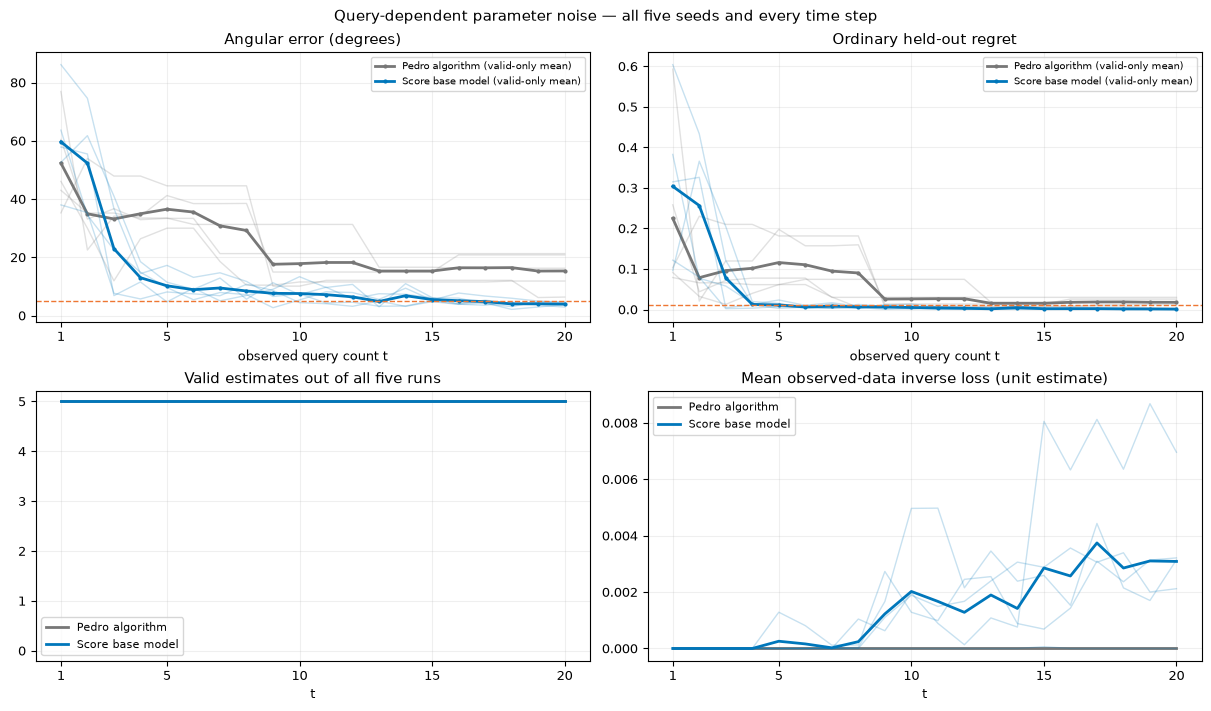

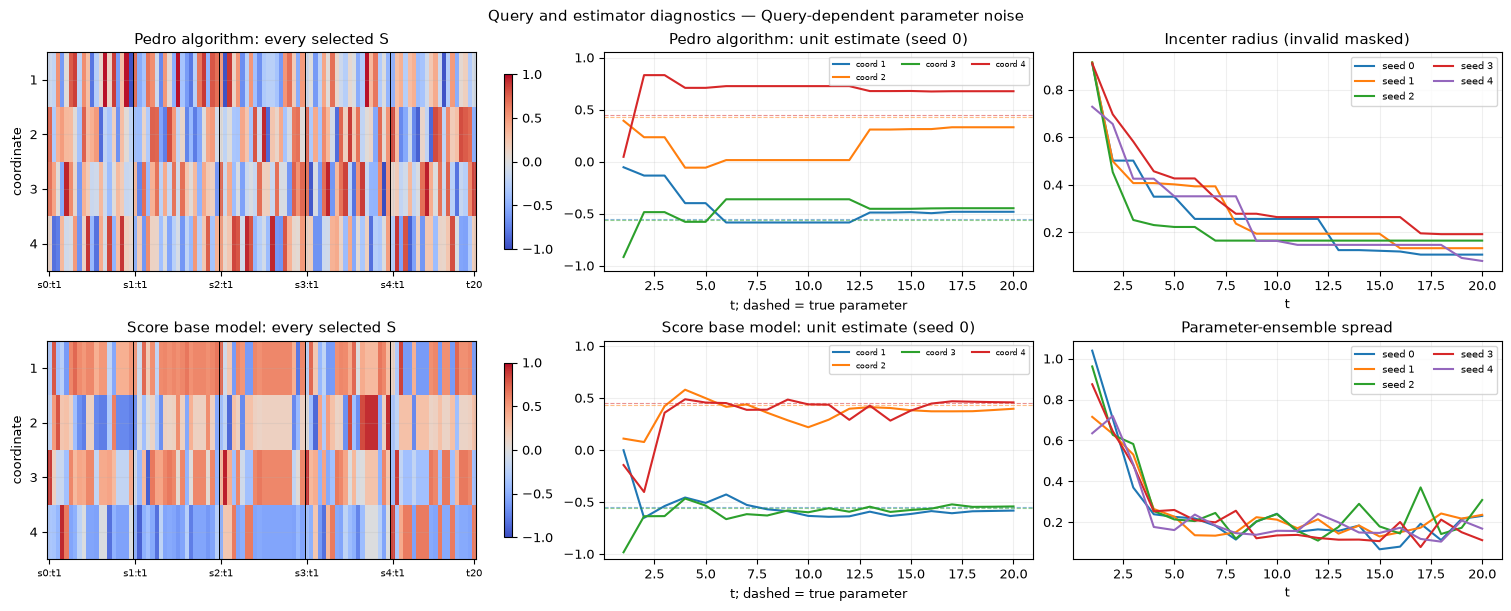

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,None,1,20
1,0,Score base model,valid,None,5,20
2,1,Pedro algorithm,valid,None,0,20
3,1,Score base model,valid,None,7,20
4,2,Pedro algorithm,valid,None,1,20
5,2,Score base model,valid,None,3,20
6,3,Pedro algorithm,valid,None,0,20
7,3,Score base model,valid,None,2,20
8,4,Pedro algorithm,valid,None,0,20
9,4,Score base model,valid,None,6,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Score base model,"[-0.0012, 0.0561, -0.5049, -0.0743]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",57.86244,0.31490,valid,None
2,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
2,Score base model,"[-0.5286, 0.0620, -0.5161, -0.3273]","[0.7870, 0.4912, 0.1455, -0.3439]","[1.0000, 0.0000, 0.0000, 0.0000]",55.47425,0.32613,valid,None
3,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[0.5341, 0.3739, 0.0193, -0.7580]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
3,Score base model,"[-0.5002, 0.3908, -0.5900, 0.3322]","[-0.3759, 0.7957, -0.1522, -0.4498]","[0.0000, 0.0000, 0.0000, 1.0000]",6.84773,0.00433,valid,None
4,Pedro algorithm,"[-0.3989, -0.0578, -0.5784, 0.7092]","[-0.6183, 0.4833, -0.5262, 0.3275]","[0.0000, 1.0000, 0.0000, 0.0000]",33.48563,0.06129,valid,None
4,Score base model,"[-0.4247, 0.5384, -0.4339, 0.4532]","[-0.2421, 0.2384, -0.1360, 0.9306]","[0.0000, 0.0000, 1.0000, 0.0000]",11.53961,0.01146,valid,None
5,Pedro algorithm,"[-0.3989, -0.0578, -0.5784, 0.7092]","[0.0178, 0.3209, 0.9417, -0.0999]","[0.0000, 0.0000, 1.0000, 0.0000]",33.48563,0.06129,valid,None
5,Score base model,"[-0.6067, 0.5939, -0.6374, 0.5437]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",4.71212,0.00286,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Score base model,"[0.0756, 0.5560, -0.1425, -0.1004]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",63.66072,0.38259,valid,None
2,Pedro algorithm,"[-0.7957, 0.4237, -0.3355, 0.2735]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",22.51927,0.02074,valid,None
2,Score base model,"[-0.0106, 0.6560, -0.2947, 0.4854]","[-0.0988, -0.0372, -0.4371, -0.8932]","[0.0000, 0.0000, 0.0000, 1.0000]",34.46721,0.07708,valid,None
3,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[-0.3454, 0.1053, 0.6798, -0.6383]","[0.0000, 0.0000, 1.0000, 0.0000]",34.13039,0.11974,valid,None
3,Score base model,"[-0.6166, 0.6141, -0.1269, 0.5282]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",22.61123,0.05787,valid,None
4,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[0.6604, -0.2836, -0.4151, 0.5579]","[1.0000, 0.0000, 0.0000, 0.0000]",34.13039,0.11974,valid,None
4,Score base model,"[-0.6115, 0.6918, -0.2960, 0.5440]","[0.1983, -0.0246, -0.9049, -0.3758]","[0.0000, 0.0000, 0.0000, 1.0000]",14.89967,0.01545,valid,None
5,Pedro algorithm,"[-0.7384, 0.5237, -0.3876, -0.1741]","[0.5532, 0.7364, 0.3663, 0.1327]","[1.0000, 0.0000, 0.0000, 0.0000]",41.21977,0.19768,valid,None
5,Score base model,"[-0.5750, 0.6649, -0.6906, 0.4269]","[0.5427, 0.1197, 0.6454, -0.5241]","[0.0000, 0.0000, 1.0000, 0.0000]",9.64106,0.00805,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Score base model,"[-0.5578, -0.2865, 0.0487, -0.0538]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",86.15365,0.60416,valid,None
2,Pedro algorithm,"[-0.3673, 0.4471, -0.8076, 0.1135]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",33.12903,0.04375,valid,None
2,Score base model,"[-0.6272, -0.1229, -0.3114, -0.2712]","[-0.1004, -0.1892, 0.9506, 0.2248]","[0.0000, 0.0000, 1.0000, 0.0000]",74.59635,0.43358,valid,None
3,Pedro algorithm,"[-0.6235, 0.2288, -0.7401, 0.1055]","[0.8838, -0.0047, 0.4124, 0.2210]","[1.0000, 0.0000, 0.0000, 0.0000]",36.68532,0.07180,valid,None
3,Score base model,"[-0.7110, 0.5199, -0.4560, 0.0235]","[0.2157, -0.8624, 0.3946, 0.2325]","[0.0000, 1.0000, 0.0000, 0.0000]",36.73096,0.12080,valid,None
4,Pedro algorithm,"[-0.5704, 0.4600, -0.6772, 0.0669]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",32.92656,0.07742,valid,None
4,Score base model,"[-0.6902, 0.5535, -0.5851, 0.4607]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",14.40239,0.01251,valid,None
5,Pedro algorithm,"[-0.5794, 0.4548, -0.6736, 0.0603]","[0.5139, -0.3504, -0.0424, 0.7819]","[1.0000, 0.0000, 0.0000, 0.0000]",33.37335,0.07742,valid,None
5,Score base model,"[-0.6451, 0.4374, -0.4291, 0.3971]","[0.5794, 0.1426, 0.5792, -0.5554]","[1.0000, 0.0000, 0.0000, 0.0000]",17.23677,0.02345,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Score base model,"[-0.0515, 0.0890, -0.6106, 0.0477]","[-0.2201, 0.0172, 0.9032, -0.3680]","[0.0000, 0.0000, 1.0000, 0.0000]",52.60040,0.09599,valid,None
2,Pedro algorithm,"[-0.1337, 0.6943, -0.6835, 0.1814]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",29.99334,0.03234,valid,None
2,Score base model,"[-0.6571, 0.1131, -0.5177, -0.3340]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",61.77641,0.36594,valid,None
3,Pedro algorithm,"[-0.2664, 0.5778, -0.5424, 0.5486]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",11.93554,0.01270,valid,None
3,Score base model,"[-0.5743, 0.5377, -0.4879, -0.1658]","[0.2157, -0.8624, 0.3946, 0.2325]","[0.0000, 1.0000, 0.0000, 0.0000]",41.01490,0.20466,valid,None
4,Pedro algorithm,"[-0.0977, 0.4553, -0.4465, 0.7641]","[-0.2237, -0.3547, -0.6248, -0.6586]","[0.0000, 0.0000, 0.0000, 1.0000]",26.36832,0.03982,valid,None
4,Score base model,"[-0.5873, 0.5982, -0.6035, 0.2342]","[-0.4439, 0.4436, -0.4654, -0.6242]","[0.0000, 0.0000, 0.0000, 1.0000]",18.51227,0.01965,valid,None
5,Pedro algorithm,"[-0.0142, 0.4265, -0.5547, 0.7143]","[0.4336, 0.5653, 0.6917, -0.1181]","[0.0000, 0.0000, 1.0000, 0.0000]",30.00601,0.06154,valid,None
5,Score base model,"[-0.6997, 0.5912, -0.4518, 0.4893]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",11.46358,0.01496,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Pedro algorithm,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Score base model,"[0.0611, 0.5142, -0.0831, 0.4168]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",37.99676,0.12178,valid,None
2,Pedro algorithm,"[-0.4874, 0.5105, 0.4492, 0.5478]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",53.94416,0.23011,valid,None
2,Score base model,"[0.1325, 0.5305, -0.5166, 0.4185]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",35.34367,0.07978,valid,None
3,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[0.3767, -0.7055, -0.1865, -0.5706]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None
3,Score base model,"[-0.3871, 0.6617, -0.5966, 0.4835]","[0.8498, 0.2669, -0.1901, 0.4128]","[1.0000, 0.0000, 0.0000, 0.0000]",7.65710,0.00212,valid,None
4,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[-0.2593, -0.5307, -0.0934, 0.8015]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None
4,Score base model,"[-0.4697, 0.6191, -0.4120, 0.5937]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 0.0000, 1.0000, 0.0000]",5.71945,0.00326,valid,None
5,Pedro algorithm,"[-0.2503, 0.8171, 0.2570, 0.4513]","[0.2912, -0.1064, 0.3235, -0.8940]","[0.0000, 0.0000, 0.0000, 1.0000]",44.54726,0.18147,valid,None
5,Score base model,"[-0.5268, 0.5276, -0.3853, 0.5024]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",8.10838,0.00720,valid,None


Completed scenario 8/8; 80/80 complete runs loaded.


In [10]:
run_and_show_family(7)

## Combined final results and recovery times

These tables include **all 80 runs**. Valid-only averages are conditional, and valid counts/failures are shown alongside them. For a fair numerical head-to-head comparison, paired wins are calculated only for pairs with two valid final estimates, while one-sided and two-sided failures are counted separately.

The recovery table lists all seeds individually. “Not reached” is never dropped when describing success rates. “Sustained” only refers to the observed remainder through T=20; it does not guarantee future stability. A numerical failure status is distinct from a large but valid angular error.

In [11]:
runs=list(ALL_RUNS.values())
assert len(runs)==80
assert {r["algorithm_name"] for r in runs}==set(LABELS)
assert all(len(r["records"])==T and r["error"] is None for r in runs)
assert all(not r["metadata"]["external_stopping_enabled"] for r in runs)
for r in runs:
    if r["algorithm_name"]==LABELS[0]:
        assert r["metadata"]["comparison_estimator"]=="incenter"
        assert all("theta_samples" not in x["update_diagnostics"] for x in r["records"])
    else:
        assert all(x["update_diagnostics"]["sampler_config"]["theta_samples"]==16 for x in r["records"])
        for record in r["records"]:
            np.testing.assert_allclose(record["theta_hat_after"],
                np.mean(record["update_diagnostics"]["theta_samples"],axis=0))
    for ev in r["metadata"]["evaluations_by_distribution"].values():
        for valid,angle,regret in zip(ev["valid_estimate_history"],
                ev["angular_error_history_degrees"],ev["normalized_regret_history"]):
            assert (angle is not None and regret is not None) if valid else (angle is None and regret is None)

summaries=[]
for design in DESIGNS[0]:
    subset=[r for r in runs if r["metadata"]["comparison_family"]==design.family]
    table=conditional_summary(subset,design.test_queries)
    table.insert(0,"scenario",design.title)
    summaries.append(table)
summary=pd.concat(summaries,ignore_index=True)
display(summary.round(4))

recovery=[]
for r in sorted(runs,key=lambda r:(r["metadata"]["comparison_family"],r["seed"],r["algorithm_name"])):
    for distribution,ev in r["metadata"]["evaluations_by_distribution"].items():
        recovery.append({
            "scenario":r["metadata"]["comparison_title"],"seed":r["seed"],
            "algorithm":r["algorithm_name"],"test":distribution,
            "final status":ev["final_status"],
            "first <=5 deg":ev["first_angular_threshold_step"],
            "sustained <=5 deg":ev["stable_angular_threshold_step"],
            "first regret<=.01":ev["first_threshold_step"],
            "sustained regret<=.01":ev["stable_threshold_step"],
            "first joint":ev["first_joint_threshold_step"],
            "sustained joint":ev["stable_joint_threshold_step"],
            "first invalid t":r["metadata"]["first_invalid_step"],
        })
recovery=pd.DataFrame(recovery)
display(HTML(recovery.to_html(index=False,na_rep="not reached / none",float_format=lambda x:f"{x:.0f}")))

pairs=[]
for design in DESIGNS[0]:
    family=design.family
    for distribution in design.test_queries:
        row={"scenario":design.title,"test":distribution,"both valid":0,
             "Pedro invalid only":0,"Score base invalid only":0,"both invalid":0,
             "Score lower angle":0,"Pedro lower angle":0,"angle tied":0,
             "Score lower regret":0,"Pedro lower regret":0,"regret tied":0}
        for seed in SEEDS:
            p=evaluation(ALL_RUNS[(family,seed,LABELS[0])],distribution)
            s=evaluation(ALL_RUNS[(family,seed,LABELS[1])],distribution)
            pv,sv=p["final_estimate_valid"],s["final_estimate_valid"]
            if pv and sv:
                row["both valid"]+=1
                for metric,column in [("final_angular_error_degrees","angle"),("final_normalized_regret","regret")]:
                    diff=s[metric]-p[metric]
                    row[("Score lower "+column) if diff < -1e-12 else
                        ("Pedro lower "+column) if diff > 1e-12 else (column+" tied")]+=1
            elif not pv and sv: row["Pedro invalid only"]+=1
            elif pv and not sv: row["Score base invalid only"]+=1
            else: row["both invalid"]+=1
        pairs.append(row)
display(pd.DataFrame(pairs))
print("ALL OUTPUTS READY: 80/80 runs, 1,600 observed steps, 8 scenarios.")
print("Per-step mean tables, all five-seed curves, full theta/S/Y tables and raw checkpoints are preserved.")
print("Final invalid runs by algorithm:",{label:sum(not evaluation(r)["final_estimate_valid"]
      for r in runs if r["algorithm_name"]==label) for label in LABELS})

,scenario,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Connecting two groups,Pedro algorithm,ordinary,4/5,1,16.7912,11.6802,0.0156,0.0112,1,1,0.1972
1,Connecting two groups,Pedro algorithm,balanced,4/5,1,16.7912,11.6802,0.0215,0.0138,1,1,0.1972
2,Connecting two groups,Score base model,ordinary,5/5,0,3.5883,0.9255,0.0027,0.0016,5,5,13.4694
3,Connecting two groups,Score base model,balanced,5/5,0,3.5883,0.9255,0.0020,0.0014,5,5,13.4694
4,Several boundaries to locate,Pedro algorithm,ordinary,4/5,1,10.2015,9.2091,0.0206,0.0225,2,2,0.0748
5,Several boundaries to locate,Score base model,ordinary,5/5,0,1.7153,0.8472,0.0004,0.0005,5,5,14.5148
6,Similar queries versus varied queries,Pedro algorithm,ordinary,5/5,0,30.5652,8.9585,0.0188,0.0135,0,2,0.1049
7,Similar queries versus varied queries,Pedro algorithm,balanced,5/5,0,30.5652,8.9585,0.0268,0.0212,0,0,0.1049
8,Similar queries versus varied queries,Score base model,ordinary,5/5,0,5.4143,3.4256,0.0005,0.0005,2,5,14.7524
9,Similar queries versus varied queries,Score base model,balanced,5/5,0,5.4143,3.4256,0.0007,0.0008,2,5,14.7524


scenario,seed,algorithm,test,final status,first <=5 deg,sustained <=5 deg,first regret<=.01,sustained regret<=.01,first joint,sustained joint,first invalid t
Ordinary balanced choice,0,Pedro algorithm,ordinary,valid,not reached / none,not reached / none,4,4,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,0,Score base model,ordinary,valid,5,17,3,5,5,17,not reached / none
Ordinary balanced choice,1,Pedro algorithm,ordinary,valid,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,1,Score base model,ordinary,valid,9,15,5,5,9,15,not reached / none
Ordinary balanced choice,2,Pedro algorithm,ordinary,valid,not reached / none,not reached / none,14,14,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,2,Score base model,ordinary,valid,6,11,5,5,6,11,not reached / none
Ordinary balanced choice,3,Pedro algorithm,ordinary,valid,not reached / none,not reached / none,8,not reached / none,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,3,Score base model,ordinary,valid,17,17,6,10,17,17,not reached / none
Ordinary balanced choice,4,Pedro algorithm,ordinary,valid,not reached / none,not reached / none,9,9,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,4,Score base model,ordinary,valid,15,15,3,3,15,15,not reached / none


,scenario,test,both valid,Pedro invalid only,Score base invalid only,both invalid,Score lower angle,Pedro lower angle,angle tied,Score lower regret,Pedro lower regret,regret tied
0,Connecting two groups,ordinary,4,1,0,0,4,0,0,3,1,0
1,Connecting two groups,balanced,4,1,0,0,4,0,0,4,0,0
2,Several boundaries to locate,ordinary,4,1,0,0,3,1,0,3,1,0
3,Similar queries versus varied queries,ordinary,5,0,0,0,5,0,0,5,0,0
4,Similar queries versus varied queries,balanced,5,0,0,0,5,0,0,5,0,0
5,Ordinary balanced choice,ordinary,5,0,0,0,5,0,0,5,0,0
6,Ordinary subset selection,ordinary,5,0,0,0,4,1,0,5,0,0
7,Small budget-constrained selection,ordinary,5,0,0,0,5,0,0,5,0,0
8,Stronger parameter noise,ordinary,5,0,0,0,5,0,0,5,0,0
9,Query-dependent parameter noise,ordinary,5,0,0,0,5,0,0,5,0,0


ALL OUTPUTS READY: 80/80 runs, 1,600 observed steps, 8 scenarios.
Per-step mean tables, all five-seed curves, full theta/S/Y tables and raw checkpoints are preserved.
Final invalid runs by algorithm: {'Pedro algorithm': 2, 'Score base model': 0}


## Independent audit of the failed incenter estimates

A homogeneous cone always contains zero. Moreover, a zero incenter radius can mean the cone has become lower-dimensional, not that every nonzero feasible direction has disappeared.

The stored legacy Pedro failure message says "no valid nonzero parameter direction." That wording is too strong: its immediate check only detects a zero returned estimate. The independent linear programs below test the geometry at the first failure and at T. A zero maximum strict margin with a nonzero feasible coordinate means **no full-dimensional interior, but nonzero feasible directions remain**. We still mark the incenter estimate invalid; we do not substitute another estimator or change the experimental results.


In [12]:
from scipy.optimize import linprog

cone_audit=[]
for run in runs:
    if run["algorithm_name"]!=LABELS[0] or run["metadata"]["first_invalid_step"] is None:
        continue
    d=len(run["true_theta"])
    # Both observed failure cases use one-hot decisions, so all alternatives are exact.
    assert run["scenario"]["decision_space"]["cardinality"]==1
    alternatives=np.eye(d)
    for t in sorted({run["metadata"]["first_invalid_step"],T}):
        normals=np.vstack([np.asarray(record["query"])*
            (np.asarray(record["observed_decision"])-alternatives)
            for record in run["records"][:t]])
        lengths=np.linalg.norm(normals,axis=1)
        normals=normals[lengths>1e-12]/lengths[lengths>1e-12,None]
        margin=linprog(np.r_[np.zeros(d),-1.],A_ub=np.c_[normals,np.ones(len(normals))],
            b_ub=np.zeros(len(normals)),bounds=[(-1,1)]*d+[(0,None)],method="highs")
        extrema=[linprog(sign*alternatives[j],A_ub=normals,b_ub=np.zeros(len(normals)),
            bounds=[(-1,1)]*d,method="highs") for j in range(d) for sign in (-1,1)]
        assert margin.success and all(result.success for result in extrema)
        largest=max(-result.fun for result in extrema)
        cone_audit.append({"scenario":run["metadata"]["comparison_title"],
            "seed":run["seed"],"t":t,"maximum strict margin (box)":-margin.fun,
            "largest feasible coordinate magnitude":largest,
            "nonzero direction exists":largest>1e-8,
            "reported estimate status":run["records"][t-1]["update_diagnostics"]["estimate_status"]})
display(pd.DataFrame(cone_audit).round(8))
print("This audit clarifies failure geometry; no run, estimate, or metric was replaced.")


,scenario,seed,t,maximum strict margin (box),largest feasible coordinate magnitude,nonzero direction exists,reported estimate status
0,Connecting two groups,3,9,-0.0,1.0,True,degenerate_cone
1,Connecting two groups,3,20,-0.0,1.0,True,degenerate_cone
2,Several boundaries to locate,4,6,-0.0,1.0,True,degenerate_cone
3,Several boundaries to locate,4,20,-0.0,1.0,True,degenerate_cone


This audit clarifies failure geometry; no run, estimate, or metric was replaced.


## Interpretation boundaries

- This is the actual Pedro-versus-Score-base comparison. Historical notebook 14 is not relabeled.
- Better results here cannot be attributed solely to query selection, because the estimators differ too.
- More reliable final decisions do not imply exact parameter recovery; angular error and regret remain separate.
- A cone failure under contradictory noisy demonstrations is an algorithmic limitation, not a fabricated large-angle output.
- Score base's finite sampling error and loss/noise-model mismatch remain possible limitations.
- The eight families include both deliberately informative-query challenges and ordinary controls. Do not select only favorable scenarios or seeds when reporting conclusions.
- Results in the notebook are permanent rendered outputs. Rerunning with changed settings or source creates a new computation rather than silently reusing incompatible checkpoints.